### Chores

In [ ]:
pip install datasets transformers emoji optuna evaluate ace_tools

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load training and validation datasets
# train_path = '/content/drive/MyDrive/ML_project/EmoTrain.csv'  # Update with your file path
# valid_path = '/content/drive/MyDrive/ML_project/EmoVal.csv'  # Update with your file path
# Load training and validation datasets
train_path = 'C:\\Users\\pouri\\Desktop\\study\\term7\\machine_learning\\assignments\\project\\ML-Project-NLP-TrVal-Datasets\\EmoTrain.csv'  # Update with your file path
valid_path = '\\Users\\pouri\\Desktop\\study\\term7\\machine_learning\\assignments\\project\\ML-Project-NLP-TrVal-Datasets\EmoVal.csv'  # Update with your file path

In [2]:
train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

In [3]:
labels_names = train_df.columns[2:].to_list()
labels_names

['praise',
 'amusement',
 'anger',
 'disapproval',
 'confusion',
 'interest',
 'sadness',
 'fear',
 'joy',
 'love']

### Preprocessing

In [4]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
MODEL_NAME='distilbert-base-uncased'
MAX_LEN=128

# ---------------------------------------------------------------------------- #
# 1. Tokenizer class
# ---------------------------------------------------------------------------- #
class EmotionTokenizer:
    def __init__(self, model_name='distilbert-base-uncased', max_len=128):
        """
        Tokenizer class for preprocessing text data.
        Args:
            model_name (str): Hugging Face model name for the tokenizer.
            max_len (int): Maximum sequence length for tokenization.
        """
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.max_len = max_len

    def tokenize_texts(self, texts):
        """
        Tokenizes a list of texts.
        Args:
            texts (list): List of text samples to tokenize.
        Returns:
            dict: Tokenized inputs with 'input_ids' and 'attention_mask'.
        """
        return self.tokenizer(
            texts,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"  # Return PyTorch tensors
        )

# ---------------------------------------------------------------------------- #
# 2. Custom Dataset returning dicts with keys "ids", "mask", "targets"
# ---------------------------------------------------------------------------- #
class EmotionDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        """
        Custom Dataset for returning dictionary-style batches.
        Args:
            input_ids (Tensor): Tensor of shape (N, max_len)
            attention_mask (Tensor): Tensor of shape (N, max_len)
            labels (Tensor): Tensor of shape (N, num_labels)
        """
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "ids": self.input_ids[idx],
            "mask": self.attention_mask[idx],
            "targets": self.labels[idx]
        }

# ---------------------------------------------------------------------------- #
# 3. Preprocessing function
# ---------------------------------------------------------------------------- #
def preprocess_data(df: pd.DataFrame, tokenizer: EmotionTokenizer, label_columns: list):
    """
    Preprocesses a pandas DataFrame for tokenization and label extraction.
    Args:
        df (pd.DataFrame): DataFrame containing text and labels.
        tokenizer (EmotionTokenizer): Instance of the EmotionTokenizer.
        label_columns (list): List of label column names.
    Returns:
        tuple: Tensors (input_ids, attention_mask, labels).
    """
    texts = df['text'].tolist()

    # Tokenize text
    encodings = tokenizer.tokenize_texts(texts)
    input_ids = encodings['input_ids']       # shape: (N, max_len)
    attention_mask = encodings['attention_mask']

    # Convert labels to float tensor
    labels_matrix = df[label_columns].values.astype(np.float32)
    labels_tensor = torch.tensor(labels_matrix)

    return input_ids, attention_mask, labels_tensor

# ---------------------------------------------------------------------------- #
# 4. Prepare DataLoader function
# ---------------------------------------------------------------------------- #
def prepare_dataloader(df: pd.DataFrame,
                       tokenizer: EmotionTokenizer,
                       label_columns: list,
                       batch_size: int,
                       shuffle: bool):
    """
    Converts a DataFrame into a PyTorch DataLoader with dict outputs.
    Args:
        df (pd.DataFrame): Input dataset.
        tokenizer (EmotionTokenizer): Tokenizer instance.
        label_columns (list): List of label column names.
        batch_size (int): Batch size for DataLoader.
        shuffle (bool): Whether to shuffle the dataset.
    Returns:
        DataLoader: PyTorch DataLoader yielding dicts with 'ids', 'mask', 'targets'.
    """
    input_ids, attention_mask, labels = preprocess_data(df, tokenizer, label_columns)

    # Create custom dataset
    dataset = EmotionDataset(input_ids, attention_mask, labels)

    # Create DataLoader
    data_loader = DataLoader(dataset,
                             batch_size=batch_size,
                             shuffle=shuffle,
                             num_workers=0)
    return data_loader

# ---------------------------------------------------------------------------- #
# 5. Main preprocessing function
# ---------------------------------------------------------------------------- #
def main_preprocessing(train_df: pd.DataFrame,
                       valid_df: pd.DataFrame,
                       label_columns,
                       model_name='distilbert-base-uncased',
                       max_len=128,
                       train_batch_size=16,
                       valid_batch_size=16):
    """
    Main function to preprocess the datasets and return DataLoaders
    that yield dictionary-style batches for DistilBERT training.
    Args:
        train_df (pd.DataFrame): Training dataset.
        valid_df (pd.DataFrame): Validation dataset.
        label_columns (list): List of label column names.
        model_name (str): Hugging Face model name for tokenizer.
        max_len (int): Maximum sequence length for tokenization.
        train_batch_size (int): Batch size for training.
        valid_batch_size (int): Batch size for validation.
    Returns:
        tuple: (DataLoader, DataLoader) for training and validation.
    """
    # Initialize tokenizer
    tokenizer = EmotionTokenizer(model_name=model_name, max_len=max_len)

    # Prepare train and validation DataLoaders
    train_loader = prepare_dataloader(train_df,
                                      tokenizer,
                                      label_columns,
                                      batch_size=train_batch_size,
                                      shuffle=True)
    valid_loader = prepare_dataloader(valid_df,
                                      tokenizer,
                                      label_columns,
                                      batch_size=valid_batch_size,
                                      shuffle=False)


    return train_loader, valid_loader

In [5]:
# Preprocess the data
train_dataset, valid_dataset = main_preprocessing(
                    train_df, valid_df,label_columns=labels_names
                    )

### Model

In [12]:
import torch
from transformers import DistilBertModel, AutoConfig

class DistilBERTClass(torch.nn.Module):
    def __init__(self, num_labels=10, hidden_dropout=0.1, attention_dropout=0.1):
        super(DistilBERTClass, self).__init__()

        config = AutoConfig.from_pretrained(
            "distilbert-base-uncased",
            dropout =hidden_dropout,# The dropout probability for all fully connected layers in the embeddings, encoder, and pooler.
            attention_dropout=attention_dropout  #  The dropout ratio for the attention probabilities.
        )

        # Load DistilBERT with custom dropout configuration
        self.l1 = DistilBertModel.from_pretrained("distilbert-base-uncased", config=config)
        self.pre_classifier = torch.nn.Linear(768, 768)
        self.dropout = torch.nn.Dropout(0.1)
        self.classifier = torch.nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask):
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0] # output = (batch_size, sequence_length, 768)
        pooler = hidden_state[:, 0] # select all sentences in batch but just the first token
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        outputs = self.classifier(pooler)
        # print(f"output len in frw pass: {len(outputs)}")
        return   outputs


    def extract_hidden_state(self, input_ids, attention_mask):
        """Return hidden state before classification"""
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]  # (batch_size, sequence_length, 768)
        return hidden_state[:, 0]  # Extract CLS token representation for all sentences in batch

### hyperparameters search space
- **dropout_rate**: Dropout rate applied to prevent overfitting.
- **attention_probs_dropout_prob**: Dropout probability for attention weights.
- **learning_rate**: Learning rate for the optimizer (e.g., 1e-5 to 5e-5 for transformers).
- **batch_size**: Number of samples per batch (common values: 32, 64).
- **L2 regularization weight_decay**: Weight decay coefficient for regularization (default: 0.0, often set between 0.01 and 0.1).
- **warmup steps**:  learning rate starts very low and gradually increases to its target value over a fixed number of steps.
- **adam_beta1** and **adam_beta2**
- **label smoothing factor**: a regularization technique that prevents a model from becoming too confident in its predictions by slightly adjusting the target labels. Instead of using hard 0s and 1s, label smoothing replaces them with softer values.

In [7]:
def suggest_parameters(trial):
    """
    Combines model hyperparameters and training hyperparameters into one dict.
    """
    params = {
        # Model hyperparameters
        "hidden_dropout": trial.suggest_float("hidden_dropout", 0.1, 0.5, step=0.05),
        "attention_dropout": trial.suggest_float("attention_dropout", 0.1, 0.5, step=0.05),

        # Training hyperparameters
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 8e-5, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1, step=0.01),
        "adam_beta1": trial.suggest_float("adam_beta1", 0.8, 0.99),
        "adam_beta2": trial.suggest_float("adam_beta2", 0.98, 0.999, step=0.001),
        "label_smoothing_factor": trial.suggest_float("label_smoothing_factor", 0.0, 0.2, step=0.01)
    }
    return params

#### labael smoothing BCE

In [8]:
import torch.nn.functional as F

def loss_fn_with_label_smoothing(outputs, targets, smoothing=0.1):
    """
    Compute BCEWithLogitsLoss with label smoothing for multi-label classification.

    Args:
        outputs (Tensor): Model logits of shape (batch_size, num_labels).
        targets (Tensor): Multi-label binary ground truth of shape (batch_size, num_labels).
        smoothing (float): Label smoothing factor (α), typically in range [0, 0.2].

    Returns:
        Tensor: Loss value.
    """
    # Apply label smoothing: Convert 1 → (1 - α), 0 → α
    smoothed_targets = targets * (1 - smoothing) + (smoothing / 2)

    # Compute BCE loss with smoothed targets
    loss = F.binary_cross_entropy_with_logits(outputs, smoothed_targets)

    return loss

### train and evaluate utils

In [9]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score,recall_score,accuracy_score, roc_auc_score, hamming_loss

def prepare_batch(batch, device):
        input_ids = batch["ids"].to(device, dtype=torch.long)
        attention_mask = batch["mask"].to(device, dtype=torch.long)
        labels = batch["targets"].to(device, dtype=torch.float)
        return input_ids, attention_mask, labels
# ------------------------------------------------
# 1) Single-epoch training loop (train_one_epoch)
# ------------------------------------------------
def train_one_epoch(model, dataloader, optimizer, device, smoothing=0.1):
    """
    Runs one training epoch.
    Returns:
        float: average loss over all batches
    """
    model.train()
    total_loss = 0.0
    for _, batch in enumerate(tqdm(dataloader, desc="Training", leave=True, mininterval=20)):

        # Extract inputs from batch
        input_ids, attention_mask, labels = prepare_batch(batch, device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Compute loss
        # loss = criterion(outputs, labels)
        loss = loss_fn_with_label_smoothing(outputs, labels, smoothing)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss


# ---------------------------------------------
# 2) Evaluation function (loss + metrics)
# ---------------------------------------------
def evaluate(model, dataloader, criterion, device, threshold=0.5, smoothing=0.0):
    """
    Evaluates the model on a given dataloader.
    Returns:
        val_loss (float),
        micro_f1 (float),
        micro_accuracy (float),
        micro_precision (float),
        roc_auc (float)
    """
    model.eval()
    total_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
          for _, batch in enumerate(tqdm(dataloader, desc="Evaluating", leave=True, mininterval=10)):
            input_ids, attention_mask, labels = prepare_batch(batch, device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # loss = criterion(outputs, labels)
            loss = loss_fn_with_label_smoothing(outputs, labels, smoothing)

            total_loss += loss.item()

            # For multi-label: use sigmoid + threshold
            probs = torch.sigmoid(outputs)  # (batch_size, num_labels)
            preds = (probs >= threshold).float()

            all_labels.append(labels.detach().cpu().numpy())
            all_preds.append(preds.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())

    # Compute average loss
    val_loss = total_loss / len(dataloader)

    # Concatenate all batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    # Convert to int for certain metrics
    all_preds_int = all_preds.astype(int)
    all_labels_int = all_labels.astype(int)

    # Micro F1
    macro_f1 = f1_score(all_labels_int, all_preds_int, average="macro", zero_division=0)

    # Micro Precision
    macro_precision = precision_score(all_labels_int, all_preds_int, average="macro", zero_division=0)

    # Micro Recall
    macro_recall = recall_score(all_labels_int, all_preds_int, average="macro", zero_division=0)


    # Accuracy (multi-label "exact match" or you could do something else)
    # We'll treat accuracy as "proportion of samples where ALL labels match exactly"
    # If you prefer a different definition for multi-label accuracy, modify accordingly.
    # exact_matches = np.all(all_preds_int == all_labels_int, axis=1)
    # hard_accuracy = exact_matches.mean()
    hard_accuracy = accuracy_score(all_labels_int, all_preds_int)


    # ROC-AUC (micro average). For multi-label, you typically pass probability estimates.
    # If you get an error for multi-label, you may need to specify multi_class="ovr" or "ovo".
    roc_auc = roc_auc_score(all_labels_int, all_preds_int, average="micro")
    avg_hamming_score = 1 - hamming_loss(all_labels_int, all_preds_int)


    return val_loss, macro_f1, hard_accuracy, macro_precision, macro_recall, roc_auc, avg_hamming_score


### variable batch size

In [8]:
from torch.utils.data import DataLoader

def build_dataloaders(dataset, batch_size, shuffle=True, num_workers=2):
    """
    Given a dataset, creates and returns a new DataLoader with the specified batch size.

    Args:
        dataset (torch.utils.data.Dataset): The dataset to wrap in a DataLoader.
        batch_size (int): The new batch size.
    Returns:
        DataLoader: A new DataLoader with the specified batch size.
    """
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

### Temp

In [13]:
from torch.utils.data import DataLoader, Subset, random_split
from math import floor

# If 'train_dataset' is actually a DataLoader, grab its underlying dataset:
#   train_dataset.dataset
# If it's already a Dataset (not a DataLoader), just use 'train_dataset' directly.
# Example:
full_train_dataset = train_dataset.dataset  # <-- only if train_dataset is a DataLoader
generator = torch.Generator().manual_seed(42)
N_SAMPLES = 174000
subset = Subset(full_train_dataset, range(N_SAMPLES))

train_split = 0.85
train_size = int(floor(train_split * N_SAMPLES))
test_size = N_SAMPLES - train_size

train_dataset_split, test_dataset_split = random_split(subset, [train_size, test_size], generator=generator)

# 3) Create new DataLoaders
train_loader =   DataLoader(train_dataset_split, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset_split, batch_size=32, shuffle=False) #TODO change name to valid_loader
#####################################
total_samples = len(full_train_dataset)
subset_indices = set(range(N_SAMPLES))
remaining_indices = list(set(range(total_samples)) - subset_indices)
remaining_dataset = Subset(full_train_dataset, remaining_indices)
combined_test_dataset = torch.utils.data.ConcatDataset([remaining_dataset, valid_dataset.dataset])
final_test_loader = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)

print(f"✅ Final test loader size: {len(final_test_loader.dataset)}")



✅ Final test loader size: 26664


In [14]:
print(len(train_dataset.dataset))
print(f"first {N_SAMPLES} samples:")
print(f"train: {len(train_loader.dataset)}")
print(f"valid: {len(test_loader.dataset)}")
print(f"test: {len(final_test_loader.dataset) }")

190102
first 174000 samples:
train: 147900
valid: 26100
test: 26664


### check dist

147900
26100


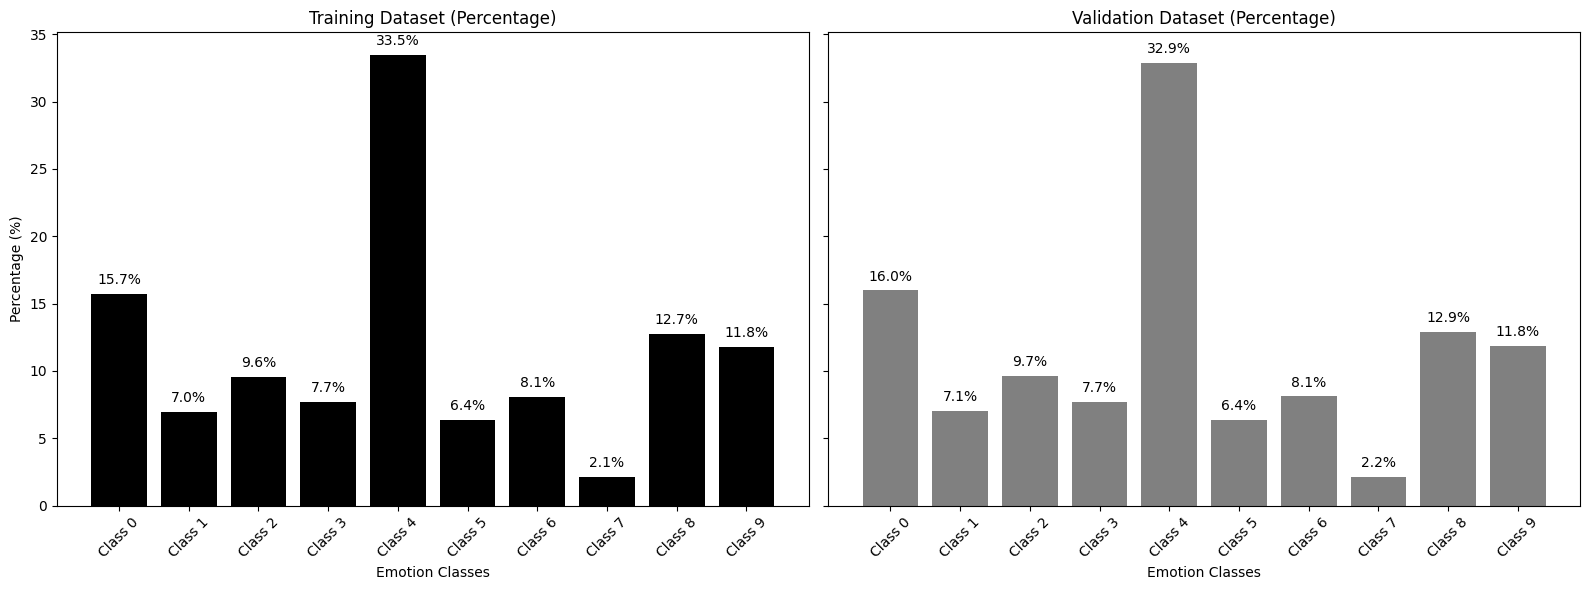

In [ ]:
import matplotlib.pyplot as plt
import torch

# Function to compute class distributions from DataLoader
def get_class_counts(dataloader, num_classes):
    class_counts = torch.zeros(num_classes)
    total_samples = 0

    for batch in dataloader:
        labels = batch["targets"]  # Extract targets from batch
        class_counts += labels.sum(dim=0)  # Sum occurrences across batches
        total_samples += labels.shape[0]

    class_percentages = (class_counts / total_samples) * 100
    return class_percentages.numpy()

# Assuming num_classes is 10 based on your dataset
num_classes = 10

# Compute class distributions
train_class_percentages = get_class_counts(train_loader, num_classes)
valid_class_percentages = get_class_counts(test_loader, num_classes)
print(len(train_loader.dataset))
print(len(test_loader.dataset))


# Define class labels
class_labels = [f"Class {i}" for i in range(num_classes)]

# Create subplots for training and validation dataset distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Training dataset plot
axes[0].bar(class_labels, train_class_percentages, color='black')
axes[0].set_title("Training Dataset (Percentage)")
axes[0].set_xlabel("Emotion Classes")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Annotate bars with percentages
for i, percentage in enumerate(train_class_percentages):
    axes[0].text(i, percentage + 0.5, f'{percentage:.1f}%', ha='center', va='bottom')

# Validation dataset plot
axes[1].bar(class_labels, valid_class_percentages, color='gray')
axes[1].set_title("Validation Dataset (Percentage)")
axes[1].set_xlabel("Emotion Classes")
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Annotate bars with percentages
for i, percentage in enumerate(valid_class_percentages):
    axes[1].text(i, percentage + 0.5, f'{percentage:.1f}%', ha='center', va='bottom')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


### Optuna Obj

In [ ]:
import os, json

global_best_micro_f1 = -1.0
best_model_dir = "drive/MyDrive/hp_search/best_model"
os.makedirs(best_model_dir, exist_ok=True)  # Ensure best_model directory exists

def objective(trial):
    global global_best_micro_f1
    print(f"👾 TRIAL{trial.number} 👾")
    # 1) Get hyperparams
    params = suggest_parameters(trial)
    print(f"HYPERPARAMETRS: {trial.params}")

    hidden_dropout = params["hidden_dropout"]
    attention_dropout = params["attention_dropout"]
    learning_rate = params["learning_rate"]
    batch_size = params["batch_size"]
    weight_decay = params["weight_decay"]
    # warmup_steps = params["warmup_steps"]
    adam_beta1 = params["adam_beta1"]
    adam_beta2 = params["adam_beta2"]
    label_smoothing_factor = params["label_smoothing_factor"]

    # 2) Initialize model
    device = torch.device("cuda")
    model = DistilBERTClass(num_labels=10,
                            hidden_dropout=hidden_dropout,
                            attention_dropout=attention_dropout)
    model.to(device)

    # 3) Create your criterion & optimizer
    criterion = nn.BCEWithLogitsLoss()  # multi-label
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(adam_beta1, adam_beta2),
        weight_decay=weight_decay
    )

    # 4) (Optional) Adjust your Dataloaders if you need dynamic batch sizes.
    #    If you want to keep them fixed from an external variable, that's fine.
    #    For example, if you have a function that re-builds them:
    #        train_loader, val_loader = build_dataloaders(batch_size=batch_size)
    #    Or if they're globally defined, you can skip.

    _train_loader = build_dataloaders(train_loader.dataset, batch_size=batch_size)
    _test_loader = build_dataloaders(test_loader.dataset, batch_size=batch_size, shuffle=False)
    print(f"🚩 train size: {len(_train_loader.dataset)}")
    print(f"🚩 valid size: {len(_test_loader.dataset)}")


    NUM_EPOCHS = 10
    best_micro_f1 = -1.0

    metrics_summary = {}
    # Early stopping parameters
    patience = 3  # Tolerated epochs without improvement
    epochs_without_improvement = 0

    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, _train_loader, optimizer=optimizer, device=device, smoothing=label_smoothing_factor)

        val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
            model, _test_loader, criterion, device
        )

        print(f"\n[Trial {trial.number}, 🤖 Epoch {epoch+1} 🤖]")
        print(f"Train Loss: {train_loss:.3f} | Validation Loss: {val_loss:.3f}")
        print(f"Micro F1: {micro_f1:.3f} | Hard Accuracy: {hard_accuracy:.3f} "
              f"| Micro Precision: {micro_precision:.3f} | Micro Recall: {micro_recall:.3f}  | ROC AUC: {roc_auc:.3f}\n")

        metrics_summary[f"Epoch {epoch+1}"] = {
            "train_loss": train_loss,
            "val_loss": val_loss,
            "micro_f1": micro_f1,
            "hard_accuracy": hard_accuracy,
            "micro_precision": micro_precision,
            "micro_recall": micro_recall,
            "roc_auc": roc_auc
        }

        # Track best micro_f1 for optional checkpoint saving per trial
        if micro_f1 > best_micro_f1:
            best_micro_f1 = micro_f1
            epochs_without_improvement = 0  # Reset patience counter
        else:
            epochs_without_improvement += 1

        if micro_f1 > global_best_micro_f1:
            global_best_micro_f1 = micro_f1
            print(f"🚀 New Best Model Found! Saving to {best_model_dir}")

            checkpoint = {
                "model_state_dict": model.state_dict(),
                "config": model.l1.config.to_dict(),
                "best_micro_f1": best_micro_f1
            }
            torch.save(checkpoint, os.path.join(best_model_dir, "best_model.pt"))

                # **Early stopping condition**
        if epochs_without_improvement >= patience:
            print(f"⏹️ Early Stopping: No improvement for {patience} consecutive epochs.")
            break

    trials_metric_dir = "drive/MyDrive/hp_search/trials_metric"
    os.makedirs(trials_metric_dir, exist_ok=True)  # Ensure trials metric directory exists

    trial_metrics_path = os.path.join(trials_metric_dir, f"trial_{trial.number}_metrics.json")
    trial_params_path = os.path.join(trials_metric_dir, f"trial_{trial.number}_params.json")

    # Save all epoch-wise metrics for this trial
    with open(trial_metrics_path, "w") as f:
        json.dump(metrics_summary, f, indent=4)

    # Save hyperparameters
    with open(trial_params_path, "w") as f:
        json.dump(params, f, indent=4)

    # 6) Return final metric to be optimized by Optuna
    return best_micro_f1

### Optuna Driver

In [ ]:
import optuna
def run_optuna_study():
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10, show_progress_bar=True)  # 10 trials

    # Print best trial
    print(f"Best trial number: {study.best_trial.number}")
    print(f"Best trial value (micro_f1): {study.best_trial.value}")
    print("Best trial params:")
    for k, v in study.best_trial.params.items():
        print(f"  {k}: {v}")

    # Let's also show a mini-table of top 3 performing trials
    print("\nTop 3 Trials (by micro_f1):")
    sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value else -9999, reverse=True)
    for t in sorted_trials[:3]:
        print(f"  - Trial #{t.number}: micro_f1={t.value:.3f}, params={t.params}")

# If you’re in a main guard:
if __name__ == "__main__":
    run_optuna_study()


[I 2025-02-02 00:09:09,318] A new study created in memory with name: no-name-bf6bcc6b-2e54-42b4-aeb0-003ebc160dfd


  0%|          | 0/10 [00:00<?, ?it/s]

👾 TRIAL0 👾
HYPERPARAMETRS: {'hidden_dropout': 0.5, 'attention_dropout': 0.2, 'learning_rate': 2.002407969464908e-05, 'batch_size': 64, 'weight_decay': 0.09, 'adam_beta1': 0.8516980330921688, 'adam_beta2': 0.982, 'label_smoothing_factor': 0.18}
🚩 train size: 147900
🚩 valid size: 26100



Training:  74%|███████▍  | 1717/2311 [04:11<01:23,  7.15it/s]
                                                             
Evaluating:   0%|          | 0/408 [00:00<?, ?it/s]
                                                   


[Trial 0, 🤖 Epoch 1 🤖]
Train Loss: 0.430 | Validation Loss: 0.362
Micro F1: 0.425 | Hard Accuracy: 0.289 | Micro Precision: 0.648 | Micro Recall: 0.316  | ROC AUC: 0.877

🚀 New Best Model Found! Saving to drive/MyDrive/hp_search/best_model


...


[Trial 9, 🤖 Epoch 5 🤖]
Train Loss: 0.279 | Validation Loss: 0.370
Micro F1: 0.466 | Hard Accuracy: 0.352 | Micro Precision: 0.599 | Micro Recall: 0.381  | ROC AUC: 0.875




Training:  69%|██████▊   | 3173/4622 [04:10<01:49, 13.22it/s]
                                                             
Evaluating:   0%|          | 0/816 [00:00<?, ?it/s]
                                                   


[Trial 9, 🤖 Epoch 6 🤖]
Train Loss: 0.274 | Validation Loss: 0.374
Micro F1: 0.465 | Hard Accuracy: 0.346 | Micro Precision: 0.573 | Micro Recall: 0.392  | ROC AUC: 0.870




Training:  69%|██████▊   | 3172/4622 [04:10<01:49, 13.22it/s]
                                                             
Evaluating:   0%|          | 0/816 [00:00<?, ?it/s]
                                                   


[Trial 9, 🤖 Epoch 7 🤖]
Train Loss: 0.269 | Validation Loss: 0.379
Micro F1: 0.457 | Hard Accuracy: 0.337 | Micro Precision: 0.573 | Micro Recall: 0.380  | ROC AUC: 0.867

⏹️ Early Stopping: No improvement for 3 consecutive epochs.
[I 2025-02-02 08:06:03,415] Trial 9 finished with value: 0.4666639330818435 and parameters: {'hidden_dropout': 0.15000000000000002, 'attention_dropout': 0.45000000000000007, 'learning_rate': 1.794769013820732e-05, 'batch_size': 32, 'weight_decay': 0.07, 'adam_beta1': 0.9845081000007616, 'adam_beta2': 0.982, 'label_smoothing_factor': 0.05}. Best is trial 1 with value: 0.4719621658141106.
Best trial number: 1
Best trial value (micro_f1): 0.4719621658141106
Best trial params:
  hidden_dropout: 0.15000000000000002
  attention_dropout: 0.1
  learning_rate: 1.6513527688014547e-05
  batch_size: 32
  weight_decay: 0.09
  adam_beta1: 0.8875886705501382
  adam_beta2: 0.991
  label_smoothing_factor: 0.18

Top 3 Trials (by micro_f1):
  - Trial #1: micro_f1=0.472, params

### load and eval

In [10]:
import torch
import json
import os

# Define model class before loading (must match training definition)
model = DistilBERTClass(num_labels=10)  # Adjust num_labels if needed

# Specify trial directory (update the trial number as needed)
# trial_dir = f"drive/MyDrive/hp_search/best_model"
trial_dir = r"hp_search\best_model"


# Load the checkpoint
checkpoint = torch.load(os.path.join(trial_dir, "best_model.pt"))

# Load model state
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()  # Set to evaluation mode
criterion = nn.BCEWithLogitsLoss()  # multi-label
device = torch.device("cuda")
model.to(device)

DistilBERTClass(
  (l1): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(i

In [15]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc,_ = evaluate(
    model, test_loader, criterion, torch.device("cuda")
)

Evaluating:   0%|          | 0/816 [00:00<?, ?it/s]C:\Users\pouri\AppData\Roaming\Python\Python310\site-packages\transformers\models\distilbert\modeling_distilbert.py:402: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Evaluating: 100%|██████████| 816/816 [01:05<00:00, 12.45it/s]


In [17]:
print(micro_f1)
print(hard_accuracy)

0.44328040137704744
0.3550574712643678


- apply weights to BCE
- apply threshold hyperparameter search
- k-fold

### memoize best models outputs (hidden state 668-d vectors)

In [11]:
from torch.utils.data import DataLoader, TensorDataset

def memoize_hidden_states(model, dataloader, device):
    """
    Extracts and memoizes hidden states (768D) from DistilBERT and returns a new DataLoader.

    Args:
        model (DistilBERTClass): The fine-tuned DistilBERT model.
        dataloader (DataLoader): Original DataLoader with tokenized input data.
        device (torch.device): The device to run computations on (CPU/GPU).

    Returns:
        DataLoader: A new DataLoader containing precomputed 768D hidden states and labels.
    """
    model.eval()
    all_hidden_states = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Processing Batches", leave=True):
        # for batch in dataloader:
            input_ids = batch["ids"].to(device, dtype=torch.long)
            attention_mask = batch["mask"].to(device, dtype=torch.long)
            labels = batch["targets"].to(device, dtype=torch.float)

            # Extract 768D hidden state from DistilBERT
            hidden_state = model.extract_hidden_state(input_ids, attention_mask)

            all_hidden_states.append(hidden_state.cpu())
            all_labels.append(labels.cpu())

    # Stack tensors and create a new dataset
    all_hidden_states = torch.cat(all_hidden_states, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    new_dataset = TensorDataset(all_hidden_states, all_labels)
    new_dataloader = DataLoader(new_dataset, batch_size=32, shuffle=True)

    return new_dataloader


In [16]:
import os
model = DistilBERTClass(num_labels=10)  # Adjust num_labels if needed
# trial_dir = r"hp_search\best_model"
trial_dir = "drive/MyDrive/hp_search/best_model"
checkpoint = torch.load(os.path.join(trial_dir, "best_model.pt"))
model.load_state_dict(checkpoint["model_state_dict"])
device = torch.device("cuda")
model.to(device)
criterion = nn.BCEWithLogitsLoss()  # multi-label
### CHECK MODEL
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda")
)
print(micro_f1)

# Load model state
memoized_train = memoize_hidden_states(model, train_loader, device=device)
memoized_valid = memoize_hidden_states(model, test_loader, device=device)
memoized_test = memoize_hidden_states(model, final_test_loader, device=device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

<ipython-input-16-21eac9e2e953>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(trial_dir, "best_model.pt"))
Processing Batches: 100%|█

### weighted BCE and tuned thresholds

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLPThreshold(nn.Module):
    # def __init__(self, num_labels=10, arch=[128], dropout=0.1):
    def __init__(self, distilbert_model, num_labels=10):
        super(MLPThreshold, self).__init__()

        # Load the pre_classifier and classifier weights from DistilBERT
        self.pre_classifier = nn.Linear(768, 768)
        self.pre_classifier.load_state_dict(distilbert_model.pre_classifier.state_dict())

        self.classifier = nn.Linear(768, num_labels)
        self.classifier.load_state_dict(distilbert_model.classifier.state_dict())

        # Learnable thresholds for each label
        self.thresholds = nn.Parameter(torch.randn(num_labels)*0.01)  # Learn only these
        print(f"initial thresholds: {self.thresholds}")

        # Freeze pre_classifier and classifier weights
        for param in self.pre_classifier.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = False

    def forward(self, hidden_state):
            """Receives 768D hidden state from DistilBERT and applies pre_classifier + classifier."""
            x = self.pre_classifier(hidden_state)
            x = torch.tanh(x)  # Same activation used in DistilBERTClass
            x = self.classifier(x)

            # Apply threshold adjustment
            adjusted_logits = x - self.thresholds.view(1, -1)

            return adjusted_logits


class CustomBCELoss(nn.Module):
    def __init__(self, num_labels=10):
        super(CustomBCELoss, self).__init__()

        # Trainable per-label weights
        self.loss_weights = nn.Parameter(torch.ones(num_labels))

    def forward(self, predictions, targets):
        """
          Accepts logits.
        """
        # Compute BCE loss with per-label weights
        # bce_loss = F.binary_cross_entropy(predictions, targets, reduction='none')
        bce_loss = F.binary_cross_entropy_with_logits(predictions, targets, reduction='none')
        weighted_loss = self.loss_weights * bce_loss
        return weighted_loss.mean()


### hp_search for best MLP

In [ ]:
import torch
import torch.optim as optim
import optuna
from sklearn.metrics import f1_score
import numpy as np
import os

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

batch_size=32
global_best_micro_f1 = -1
best_model_state_dict = None


# Define the objective function for Optuna
def objective(trial):
    global global_best_micro_f1
    num_epochs = 15  # Number of epochs
    NUM_LABELS = 10

        # Define hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    beta1 = trial.suggest_float("beta1", 0.8, 0.99)
    beta2 = trial.suggest_float("beta2", 0.9, 0.999)
    # dropout = trial.suggest_float("dropout", 0.1, 0.5)
    # arch_space = [(128, ), ()]
    # arch = trial.suggest_categorical("arch", arch_space)
    # arch = list(arch)

    # Define MLP model
    # mlp = MLPThreshold(num_labels=NUM_LABELS, arch=arch, dropout=dropout).to(device)
    mlp = MLPThreshold(distilbert_model=model, num_labels=NUM_LABELS).to(device)
    # loss_fn = CustomBCELoss(num_labels=NUM_LABELS).to(device)
    loss_fn = torch.nn.BCEWithLogitsLoss().to(device)


    optimizer = optim.AdamW(list(mlp.parameters()) , lr=lr, betas=(beta1, beta2))


    total_params = count_parameters(mlp)
    print(f"\n🚀 Starting new trial with {total_params:,} trainable parameters\n")
    print(mlp)


    print(f"🚩 train size: {len(memoized_train.dataset)}")
    print(f"🚩 valid size: {len(memoized_valid.dataset)}")

    best_micro_f1 = 0
    patience = 3
    no_improvement = 0
    for epoch in range(num_epochs):
        mlp.train()
        for batch in memoized_train:
            hidden_states = batch[0].to(device, dtype=torch.float)  # 768D embeddings
            labels = batch[1].to(device, dtype=torch.float)  # Labels

            # Train MLP on these logits
            predictions = mlp(hidden_states)
            loss = loss_fn(predictions, labels)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Evaluation after each epoch
        mlp.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in memoized_valid:

                hidden_states = batch[0].to(device, dtype=torch.float)  # 768D embeddings
                labels = batch[1].to(device, dtype=torch.float)  # Labels

                # Get final predictions from MLP
                predictions = mlp(hidden_states)

                # Convert predictions to binary (0 or 1) using threshold 0.5
                binary_predictions = (predictions.cpu().numpy() > 0.5).astype(int)
                true_labels = labels.cpu().numpy()

                all_preds.append(binary_predictions)
                all_labels.append(true_labels)

        # Compute micro F1-score
        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)
        micro_f1 = f1_score(all_labels, all_preds, average="micro")
        # micro_f1 = accuracy_score(all_labels, all_preds)

        print(f"📊 Epoch {epoch+1} | Micro F1-Score: {micro_f1:.3f}")
        # print(f"📊 Epoch {epoch+1} |  Hard Accuracy: {micro_f1:.3f}")


        if micro_f1 > best_micro_f1:
            best_micro_f1 = micro_f1
            no_improvement = 0
        else:
            no_improvement += 1

        if micro_f1 > global_best_micro_f1:
            global_best_micro_f1 = micro_f1  # Track the best F1-score

            # Save the best model's state
            # save_dir = "drive/MyDrive/hp_search/MLP_BCE"
            save_dir = "hp_search/MLP_BCE"
            os.makedirs(save_dir, exist_ok=True)
            torch.save({
                "mlp_state_dict": mlp.state_dict(),
                "loss_fn_state_dict": loss_fn.state_dict(),
            },  os.path.join(save_dir, "best.pt"))
        if no_improvement > patience:
            break
    print(mlp.thresholds)


    return best_micro_f1  # We want to maximize this metric

# Optimize with Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10,show_progress_bar=True)

# Load the best model's weights
best_checkpoint = torch.load("hp_search/MLP_BCE/best.pt", map_location=device)

best_mlp = MLPThreshold(num_labels=10).to(device)
best_mlp.load_state_dict(best_checkpoint["mlp_state_dict"])

best_loss_fn = CustomBCELoss(num_labels=10)
best_loss_fn.load_state_dict(best_checkpoint["loss_fn_state_dict"])

# Print results
print("Best hyperparameters:", study.best_params)
print("Learned Threshold Weights:", best_mlp.thresholds.data.cpu().numpy())

### test different thresholds manually

#### Valid

In [23]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda"),smoothing=0
)
print(f"macro_f1 (0.5th): {micro_f1}")
print(f"hard_accuracy (0.5th): {hard_accuracy}")
print(f"macro_precision (0.5th): {micro_precision}")
print(f"macro_recall (0.5th): {micro_recall}")
print(f"roc_auc (0.5th): {roc_auc}")


Evaluating: 100%|██████████| 816/816 [01:07<00:00, 12.00it/s]

macro_f1 (0.5th): 0.44328040137704744
hard_accuracy (0.5th): 0.3550574712643678
micro_precision (0.5th): 0.5587805101014718
micro_recall (0.5th): 0.40849400207170783
roc_auc (0.5th): 0.6833596624026081


In [17]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda"), threshold=0.3
)
print(f"macro_f1 (0.3th): {micro_f1}")
print(f"hard_accuracy (0.3th): {hard_accuracy}")
print(f"macro_precision (0.3th): {micro_precision}")
print(f"macro_recall (0.3th): {micro_recall}")
print(f"roc_auc (0.3th): {roc_auc}")

Evaluating: 100%|██████████| 816/816 [01:06<00:00, 12.28it/s]

macro_f1 (0.3th): 0.4864993948524453
hard_accuracy (0.3th): 0.30168582375478925
macro_precision (0.3th): 0.45224137059685654
macro_recall (0.3th): 0.5980218531760617
roc_auc (0.3th): 0.7521058359889561


In [18]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda"), threshold=0.35
)
print(f"macro_f1 (0.35th): {micro_f1}")
print(f"hard_accuracy (0.35th): {hard_accuracy}")
print(f"macro_precision (0.35th): {micro_precision}")
print(f"macro_recall (0.35th): {micro_recall}")
print(f"roc_auc (0.35th): {roc_auc}")

Evaluating: 100%|██████████| 816/816 [01:07<00:00, 12.10it/s]

macro_f1 (0.35th): 0.4843646267559227
hard_accuracy (0.35th): 0.3474712643678161
macro_precision (0.35th): 0.4834813499111901
macro_recall (0.35th): 0.5457279379824239
roc_auc (0.35th): 0.7351096662384022


In [19]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda"), threshold=0.38
)
print(f"macro_f1 (0.38th): {micro_f1}")
print(f"hard_accuracy (0.38th): {hard_accuracy}")
print(f"macro_precision (0.38th): {micro_precision}")
print(f"macro_recall (0.38th): {micro_recall}")
print(f"roc_auc (0.38th): {roc_auc}")

Evaluating: 100%|██████████| 816/816 [01:08<00:00, 11.83it/s]

macro_f1 (0.38th): 0.4803496568475706
hard_accuracy (0.38th): 0.36310344827586205
macro_precision (0.38th): 0.5003079316715827
macro_recall (0.38th): 0.5157550038426839
roc_auc (0.38th): 0.7245200780769291


In [20]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda"), threshold=0.40
)
print(f"macro_f1 (0.4th): {micro_f1}")
print(f"hard_accuracy (0.4th): {hard_accuracy}")
print(f"macro_precision (0.4th): {micro_precision}")
print(f"macro_recall (0.4th): {micro_recall}")
print(f"roc_auc (0.40th): {roc_auc}")

Evaluating: 100%|██████████| 816/816 [01:11<00:00, 11.49it/s]

macro_f1 (0.4th): 0.4767410349123355
hard_accuracy (0.4th): 0.37091954022988505
macro_precision (0.4th): 0.5104262968669748
macro_recall (0.4th): 0.49811207271026164
roc_auc (0.40th): 0.7181177614376805


In [20]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, test_loader, criterion, torch.device("cuda"), threshold=0.42
)
print(f"macro_f1 (0.42th): {micro_f1}")
print(f"hard_accuracy (0.42th): {hard_accuracy}")
print(f"macro_precision (0.42th): {micro_precision}")
print(f"macro_recall (0.42th): {micro_recall}")
print(f"roc_auc (0.42th): {roc_auc}")

Evaluating: 100%|██████████| 816/816 [01:24<00:00,  9.67it/s]

micro_f1 (0.42th): 0.4715285202746373
hard_accuracy (0.42th): 0.3731417624521073
micro_precision (0.42th): 0.5215506248406019
micro_recall (0.42th): 0.47833060447087916
roc_auc (0.42th): 0.7107500395262525


#### Test

In [47]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda")
)
print(f"macro_f1 (0.5th): {micro_f1}")
print(f"hard_accuracy (0.5th): {hard_accuracy}")
print(f"micro_precision (0.5th): {micro_precision}")
print(f"micro_recall (0.5th): {micro_recall}")
print(f"roc_auc (0.5th): {roc_auc}")


Evaluating: 100%|██████████| 834/834 [00:42<00:00, 19.67it/s]


macro_f1 (0.5th): 0.4439059139164052
hard_accuracy (0.5th): 0.35471047104710474
micro_precision (0.5th): 0.558818279186005
micro_recall (0.5th): 0.409563681559495
roc_auc (0.5th): 0.6838427813641603


In [48]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda"), threshold=0.42
)
print(f"macro_f1 (0.42th): {micro_f1}")
print(f"hard_accuracy (0.42th): {hard_accuracy}")
print(f"micro_precision (0.42th): {micro_precision}")
print(f"micro_recall (0.42th): {micro_recall}")
print(f"roc_auc (0.42th): {roc_auc}")

Evaluating: 100%|██████████| 834/834 [00:42<00:00, 19.42it/s]


macro_f1 (0.42th): 0.467881117591406
hard_accuracy (0.42th): 0.36877437743774377
micro_precision (0.42th): 0.5183218079418265
micro_recall (0.42th): 0.4756001831621639
roc_auc (0.42th): 0.7091788585360861


In [49]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda"), threshold=0.40
)
print(f"macro_f1 (0.4th): {micro_f1}")
print(f"hard_accuracy (0.4th): {hard_accuracy}")
print(f"micro_precision (0.4th): {micro_precision}")
print(f"micro_recall (0.4th): {micro_recall}")
print(f"roc_auc (0.40th): {roc_auc}")

Evaluating: 100%|██████████| 834/834 [00:41<00:00, 19.93it/s]


macro_f1 (0.4th): 0.47208642878954254
hard_accuracy (0.4th): 0.36656165616561653
micro_precision (0.4th): 0.5073712554695389
micro_recall (0.4th): 0.49303329626480014
roc_auc (0.40th): 0.7155168429931593


In [50]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda"), threshold=0.38
)
print(f"macro_f1 (0.38th): {micro_f1}")
print(f"hard_accuracy (0.38th): {hard_accuracy}")
print(f"micro_precision (0.38th): {micro_precision}")
print(f"micro_recall (0.38th): {micro_recall}")
print(f"roc_auc (0.38th): {roc_auc}")

Evaluating: 100%|██████████| 834/834 [00:42<00:00, 19.78it/s]


macro_f1 (0.38th): 0.4759799279570391
hard_accuracy (0.38th): 0.3615361536153615
micro_precision (0.38th): 0.4963837076513133
micro_recall (0.38th): 0.5118074180676392
roc_auc (0.38th): 0.7222775197477725


In [51]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda"), threshold=0.38
)
print(f"macro_f1 (0.38th): {micro_f1}")
print(f"hard_accuracy (0.38th): {hard_accuracy}")
print(f"micro_precision (0.38th): {micro_precision}")
print(f"micro_recall (0.38th): {micro_recall}")
print(f"roc_auc (0.38th): {roc_auc}")

Evaluating: 100%|██████████| 834/834 [00:42<00:00, 19.44it/s]


macro_f1 (0.38th): 0.4759799279570391
hard_accuracy (0.38th): 0.3615361536153615
micro_precision (0.38th): 0.4963837076513133
micro_recall (0.38th): 0.5118074180676392
roc_auc (0.38th): 0.7222775197477725


In [52]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda"), threshold=0.35
)
print(f"macro_f1 (0.35th): {micro_f1}")
print(f"hard_accuracy (0.35th): {hard_accuracy}")
print(f"micro_precision (0.35th): {micro_precision}")
print(f"micro_recall (0.35th): {micro_recall}")
print(f"roc_auc (0.35th): {roc_auc}")

Evaluating: 100%|██████████| 834/834 [00:42<00:00, 19.47it/s]


macro_f1 (0.35th): 0.4798942380492261
hard_accuracy (0.35th): 0.3446219621962196
micro_precision (0.35th): 0.47844139252634943
micro_recall (0.35th): 0.5389546673644273
roc_auc (0.35th): 0.7314307704329528


In [54]:
val_loss, micro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc = evaluate(
    model, final_test_loader, criterion, torch.device("cuda"), threshold=0.3
)
print(f"macro_f1 (0.3th): {micro_f1}")
print(f"hard_accuracy (0.3th): {hard_accuracy}")
print(f"micro_precision (0.3th): {micro_precision}")
print(f"micro_recall (0.3th): {micro_recall}")
print(f"roc_auc (0.3th): {roc_auc}")

Evaluating: 100%|██████████| 834/834 [00:44<00:00, 18.92it/s]


macro_f1 (0.3th): 0.4813641149434025
hard_accuracy (0.3th): 0.2988298829882988
micro_precision (0.3th): 0.44664883340763856
micro_recall (0.3th): 0.5898148753843134
roc_auc (0.3th): 0.7475880439632844


### Train  model with the found hyperparameters WITH weighted BCE

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DistilBERTClassifierOnly(nn.Module):
    def __init__(self, dropout=0.1, num_labels=10, activation="tanh"):
        super(DistilBERTClassifierOnly, self).__init__()
        self.pre_classifier = nn.Linear(768, 768)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_labels)

        # Activation function mapping
        self.activation_funcs = {
            "gelu": nn.GELU(),
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "silu": nn.SiLU()
        }

        self.activation = self.activation_funcs[activation]

    def forward(self, hidden_states):
        x = self.pre_classifier(hidden_states)
        x = self.activation(x)  # Dynamically apply the chosen activation
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits


In [20]:
len(memoized_valid.dataset)

26100

In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#### Hyperparameter search with BCE weights

In [27]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
from torch.utils.data import DataLoader

# Device setup
device = torch.device("cuda")

# Define loss function with dynamic weights
class WeightedBCELoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.weights = weights  # Dynamic per trial

    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.weights, reduction='sum')

# Function to train classifier on memoized features
def objective(trial):
    global memoized_train, memoized_valid


    # Define dynamic BCE weights as hyperparameters
    bce_weights = torch.tensor(
        [trial.suggest_categorical(f"w_{label}", [i * 0.5 for i in range(1, 11)]) for label in [
            'praise', 'amusement', 'anger', 'disapproval', 'confusion',
            'interest', 'sadness', 'fear', 'joy', 'love'
        ]], device=device
    )
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "adam_beta1": trial.suggest_float("adam_beta1", 0.8, 0.99),
        "adam_beta2": trial.suggest_float("adam_beta2", 0.9, 0.999),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "activation": trial.suggest_categorical("activation", ["gelu", "relu", "tanh", "silu"])
    }


    print(f"\n🔎 Trial {trial.number} - Assigned BCE Weights:", bce_weights.tolist())

    # Define loss function
    weighted_bce = WeightedBCELoss(weights=bce_weights).to(device)



    # Training loop
    EPOCHS = 10
    patience = 3  # Early stopping patience
    epochs_without_improvement = 0
    best_macro_f1 = -1
    metrics_summary = {}

    print(f"🚩 train size: {len(memoized_train.dataset)}")
    print(f"🚩 valid size: {len(memoized_valid.dataset)}")

    best_model_dir = f"drive/MyDrive/hp_search/macro_weightedBCE/trial_{trial.number}"
    os.makedirs(best_model_dir, exist_ok=True)

    classifier_model = DistilBERTClassifierOnly(dropout=params["dropout"], activation=params["activation"]).to(device)
    total_params = count_parameters(classifier_model)
    print(f"\n🚀 Starting new trial with {total_params:,} trainable parameters\n")

    # Optimizer
    optimizer = torch.optim.AdamW(
        classifier_model.parameters(),
        lr=params['learning_rate'],
        betas=(params['adam_beta1'], params['adam_beta2']),
        weight_decay=params['weight_decay']
    )


    for epoch in range(EPOCHS):
        total_loss = 0.0
        classifier_model.train()
        # for batch in memoized_train:
        for batch in tqdm(memoized_train, desc="Processing Batches", leave=True):
            hidden_states = batch[0].to(device, dtype=torch.float)  # 768D embeddings
            labels = batch[1].to(device, dtype=torch.float)  # Labels

            # Train MLP on these logits
            predictions = classifier_model(hidden_states)
            loss = weighted_bce(predictions, labels)
            total_loss += loss.item()

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss = total_loss / len(memoized_train)


        classifier_model.eval()
        total_loss = 0.0
        all_labels = []
        all_preds = []
        all_probs = []
        with torch.no_grad():
            for batch in memoized_valid:

                hidden_states = batch[0].to(device, dtype=torch.float)  # 768D embeddings
                labels = batch[1].to(device, dtype=torch.float)  # Labels

                # Get final predictions from MLP
                predictions = classifier_model(hidden_states)
                loss = weighted_bce(predictions, labels)
                total_loss += loss.item()
                probs = torch.sigmoid(predictions)  # (batch_size, num_labels)
                preds = (probs >= 0.5).float()

                all_labels.append(labels.detach().cpu().numpy())
                all_preds.append(preds.detach().cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())
        val_loss = total_loss / len(memoized_valid)

        # Concatenate all batches
        all_labels = np.concatenate(all_labels, axis=0)
        all_preds = np.concatenate(all_preds, axis=0)

        # Convert to int for certain metrics
        all_preds_int = all_preds.astype(int)
        all_labels_int = all_labels.astype(int)

        macro_f1 = f1_score(all_labels_int, all_preds_int, average="macro", zero_division=0)
        macro_precision = precision_score(all_labels_int, all_preds_int, average="macro", zero_division=0)
        macro_recall = recall_score(all_labels_int, all_preds_int, average="macro", zero_division=0)
        hard_accuracy = accuracy_score(all_labels_int, all_preds_int)
        roc_auc = roc_auc_score(all_labels_int, all_preds_int, average="macro")



        print(f"\n🤖 Epoch {epoch+1} 🤖")
        print(f"Train Loss: {train_loss:.3f} | Validation Loss: {val_loss:.3f}")
        print(f"Macro F1: {macro_f1:.3f} | Hard Accuracy: {hard_accuracy:.3f} "
              f"| Macro Precision: {macro_precision:.3f} | Macro Recall: {macro_recall:.3f} | ROC AUC: {roc_auc:.3f}")

        metrics_summary[f"Epoch {epoch+1}"] = {
            "train_loss": train_loss,
            "val_loss": val_loss,
            "macro_f1": macro_f1,
            "hard_accuracy": hard_accuracy,
            "macro_precision": macro_precision,
            "macro_recall": macro_recall,
            "roc_auc": roc_auc
        }

        # Track best model based on macro F1
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            epochs_without_improvement = 0
            print(f"🚀 New Best Model Found! Saving to {best_model_dir}")

            checkpoint = {
                "model_state_dict": classifier_model.state_dict(),
                "bce_weights": bce_weights.tolist(),
                "best_macro_f1": best_macro_f1
            }
            torch.save(checkpoint, os.path.join(best_model_dir, "best_model.pt"))

        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"⏹️ Early Stopping: No improvement for {patience} consecutive epochs.")
                break

    # Save all epoch-wise metrics for this trial
    trial_metrics_path = os.path.join(best_model_dir, "trial_metrics.json")
    with open(trial_metrics_path, "w") as f:
        json.dump(metrics_summary, f, indent=4)

    # Save the BCE weights found in this trial
    trial_params_path = os.path.join(best_model_dir, "trial_params.json")
    with open(trial_params_path, "w") as f:
        json.dump({"bce_weights": bce_weights.tolist()}, f, indent=4)

    return best_macro_f1  # Optuna will maximize this

# Run hyperparameter optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

# Best trial info
best_trial = study.best_trial
print(f"\n🏆 Best Trial ID: {best_trial.number}")
print(f"Best Macro F1 Score: {best_trial.value}")
print("Best BCE Weights:", best_trial.params)

# Save best trial info
best_trial_path = "drive/MyDrive/hp_search/macro_weightedBCE/best_trial.json"
with open(best_trial_path, "w") as f:
    json.dump(best_trial.params, f, indent=4)


[I 2025-02-02 20:48:50,866] A new study created in memory with name: no-name-2598a9fe-643f-4df8-b4a9-f7136e7d4370



🔎 Trial 0 - Assigned BCE Weights: [4.0, 2.0, 0.5, 5.0, 4.0, 3.5, 4.5, 2.0, 1.0, 4.5]
🚩 train size: 147900
🚩 valid size: 26100

🚀 Starting new trial with 598,282 trainable parameters



Processing Batches: 100%|██████████| 4622/4622 [00:08<00:00, 526.24it/s]



🤖 Epoch 1 🤖
Train Loss: 112.424 | Validation Loss: 166.754
Macro F1: 0.466 | Hard Accuracy: 0.324 | Macro Precision: 0.464 | Macro Recall: 0.503 | ROC AUC: 0.705
🚀 New Best Model Found! Saving to drive/MyDrive/hp_search/macro_weightedBCE/trial_0


Processing Batches: 100%|██████████| 4622/4622 [00:08<00:00, 529.41it/s]


...


🤖 Epoch 2 🤖
Train Loss: 92.126 | Validation Loss: 139.369
Macro F1: 0.462 | Hard Accuracy: 0.329 | Macro Precision: 0.474 | Macro Recall: 0.479 | ROC AUC: 0.705


Processing Batches: 100%|██████████| 4622/4622 [00:08<00:00, 530.16it/s]



🤖 Epoch 3 🤖
Train Loss: 91.455 | Validation Loss: 139.998
Macro F1: 0.462 | Hard Accuracy: 0.330 | Macro Precision: 0.473 | Macro Recall: 0.480 | ROC AUC: 0.705


Processing Batches: 100%|██████████| 4622/4622 [00:08<00:00, 539.07it/s]
[I 2025-02-02 21:00:18,585] Trial 14 finished with value: 0.4632558866692529 and parameters: {'w_praise': 4.5, 'w_amusement': 2.5, 'w_anger': 3.5, 'w_disapproval': 4.0, 'w_confusion': 0.5, 'w_interest': 5.0, 'w_sadness': 0.5, 'w_fear': 4.5, 'w_joy': 1.5, 'w_love': 1.5, 'learning_rate': 1.361594590165505e-05, 'adam_beta1': 0.8267469850925537, 'adam_beta2': 0.9267967096210851, 'weight_decay': 2.0188108587482357e-06, 'dropout': 0.16649199562114256, 'activation': 'tanh'}. Best is trial 3 with value: 0.47534027019287145.



🤖 Epoch 4 🤖
Train Loss: 91.014 | Validation Loss: 140.432
Macro F1: 0.461 | Hard Accuracy: 0.328 | Macro Precision: 0.471 | Macro Recall: 0.480 | ROC AUC: 0.705
⏹️ Early Stopping: No improvement for 3 consecutive epochs.

🏆 Best Trial ID: 3
Best Macro F1 Score: 0.47534027019287145
Best BCE Weights: {'w_praise': 4.0, 'w_amusement': 4.5, 'w_anger': 4.0, 'w_disapproval': 3.0, 'w_confusion': 3.5, 'w_interest': 2.5, 'w_sadness': 5.0, 'w_fear': 3.5, 'w_joy': 5.0, 'w_love': 1.5, 'learning_rate': 0.00034586457651249473, 'adam_beta1': 0.8729124536870028, 'adam_beta2': 0.9294120414295047, 'weight_decay': 1.4915334847129862e-05, 'dropout': 0.13440167649050694, 'activation': 'silu'}


- evaluate on test done
- ui
- compare before and after

#### load best model head

In [42]:
import torch
import json

# Define device
device = torch.device("cuda")

# Load the checkpoint
checkpoint_path = "drive/MyDrive/hp_search/macro_weightedBCE/trial_3/best_model.pt"  # Replace X with the best trial number
checkpoint = torch.load(checkpoint_path, map_location=device)

# Print best micro F1-score stored in the checkpoint
print(f"Loaded Model - Best Macro F1 Score: {checkpoint['best_macro_f1']:.3f}")


# Load model parameters
params_path = "drive/MyDrive/hp_search/macro_weightedBCE/best_trial.json"  # Replace X with trial number
with open(params_path, "r") as f:
    model_params = json.load(f)

# Extract activation function and dropout from saved params
dropout = model_params.get("dropout")  # Default 0.1 if not found
activation = model_params.get("activation")  # Default 'relu' if not found

# Recreate the model
best_model_head = DistilBERTClassifierOnly(dropout=dropout, activation=activation).to(device)

# Load model weights
best_model_head.load_state_dict(checkpoint["model_state_dict"])
best_model_head.eval()  # Set to evaluation mode
print("✅ Model weights loaded successfully.")
print(best_model_head)

# load weightedBCE
bce_weights = torch.tensor(checkpoint["bce_weights"], device=device)
weighted_bce = WeightedBCELoss(weights=bce_weights).to(device)


Loaded Model - Best Macro F1 Score: 0.475
✅ Model weights loaded successfully.
DistilBERTClassifierOnly(
  (pre_classifier): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.13440167649050694, inplace=False)
  (classifier): Linear(in_features=768, out_features=10, bias=True)
  (activation): SiLU()
)


<ipython-input-42-c3394a83ff60>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


#### utils2

In [52]:
def classifier_evaluate(classifier_model, memoized_valid,weighted_bce,threshold=0.5):
    classifier_model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for batch in memoized_valid:

            hidden_states = batch[0].to(device, dtype=torch.float)  # 768D embeddings
            labels = batch[1].to(device, dtype=torch.float)  # Labels

            # Get final predictions from MLP
            predictions = classifier_model(hidden_states)
            loss = weighted_bce(predictions, labels)
            total_loss += loss.item()
            probs = torch.sigmoid(predictions)  # (batch_size, num_labels)
            preds = (probs >= threshold).float()

            all_labels.append(labels.detach().cpu().numpy())
            all_preds.append(preds.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())
    val_loss = total_loss / len(memoized_valid)

    # Concatenate all batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    # Convert to int for certain metrics
    all_preds_int = all_preds.astype(int)
    all_labels_int = all_labels.astype(int)

    macro_f1 = f1_score(all_labels_int, all_preds_int, average="macro", zero_division=0)
    macro_precision = precision_score(all_labels_int, all_preds_int, average="macro", zero_division=0)
    macro_recall = recall_score(all_labels_int, all_preds_int, average="macro", zero_division=0)
    hard_accuracy = accuracy_score(all_labels_int, all_preds_int)
    roc_auc = roc_auc_score(all_labels_int, all_preds_int, average="macro")
    return macro_f1, macro_precision, macro_recall, hard_accuracy, roc_auc, val_loss


#### valid

In [51]:
macro_f1, macro_precision, macro_recall, hard_accuracy, roc_auc, val_loss = classifier_evaluate(
    classifier_model=best_model_head,
    memoized_valid=memoized_valid,
    weighted_bce=weighted_bce)

print(f"macro_f1 (0.5th): {macro_f1}")
print(f"hard_accuracy (0.5th): {hard_accuracy}")
print(f"macro_precision (0.5th): {macro_precision}")
print(f"macro_recall (0.5th): {macro_recall}")
print(f"roc_auc (0.5th): {roc_auc}")

print("SANITY CHECK PASSED")

macro_f1 (0.5th): 0.47534027019287145
hard_accuracy (0.5th): 0.2806130268199234
macro_precision (0.5th): 0.421929452853054
macro_recall (0.5th): 0.5541026306024758
roc_auc (0.5th): 0.720682007080042
SANITY CHECK PASSED


#### test

In [50]:
macro_f1, macro_precision, macro_recall, hard_accuracy, roc_auc, val_loss = classifier_evaluate(
    classifier_model=best_model_head,
    memoized_valid=memoized_test,
    weighted_bce=weighted_bce)

print(f"macro_f1 (0.5th): {macro_f1}")
print(f"hard_accuracy (0.5th): {hard_accuracy}")
print(f"macro_precision (0.5th): {macro_precision}")
print(f"macro_recall (0.5th): {macro_recall}")
print(f"roc_auc (0.5th): {roc_auc}")

macro_f1 (0.5th): 0.47499832877651105
hard_accuracy (0.5th): 0.2806030603060306
macro_precision (0.5th): 0.4211128496017724
macro_recall (0.5th): 0.554288846319281
roc_auc (0.5th): 0.7204953370555502


In [54]:
macro_f1, macro_precision, macro_recall, hard_accuracy, roc_auc, val_loss = classifier_evaluate(
    classifier_model=best_model_head,
    memoized_valid=memoized_test,
    weighted_bce=weighted_bce,
    threshold=0.4)

print(f"macro_f1 (0.4th): {macro_f1}")
print(f"hard_accuracy (0.4th): {hard_accuracy}")
print(f"macro_precision (0.4th): {macro_precision}")
print(f"macro_recall (0.4th): {macro_recall}")
print(f"roc_auc (0.4th): {roc_auc}")

macro_f1 (0.4th): 0.4671068672890817
hard_accuracy (0.4th): 0.23034803480348034
macro_precision (0.4th): 0.3868220419251163
macro_recall (0.4th): 0.6023435051191004
roc_auc (0.4th): 0.7313680710285191


In [55]:
macro_f1, macro_precision, macro_recall, hard_accuracy, roc_auc, val_loss = classifier_evaluate(
    classifier_model=best_model_head,
    memoized_valid=memoized_test,
    weighted_bce=weighted_bce,
    threshold=0.35)

print(f"macro_f1 (0.35th): {macro_f1}")
print(f"hard_accuracy (0.35th): {hard_accuracy}")
print(f"macro_precision (0.35th): {macro_precision}")
print(f"macro_recall (0.35th): {macro_recall}")
print(f"roc_auc (0.35th): {roc_auc}")

macro_f1 (0.35th): 0.46259248978301404
hard_accuracy (0.35th): 0.20754575457545754
macro_precision (0.35th): 0.3713252902677011
macro_recall (0.35th): 0.6279879250929938
roc_auc (0.35th): 0.7369038137889132


In [57]:
macro_f1, macro_precision, macro_recall, hard_accuracy, roc_auc, val_loss = classifier_evaluate(
    classifier_model=best_model_head,
    memoized_valid=memoized_test,
    weighted_bce=weighted_bce,
    threshold=0.42)

print(f"macro_f1 (0.42th): {macro_f1}")
print(f"hard_accuracy (0.42th): {hard_accuracy}")
print(f"macro_precision (0.42th): {macro_precision}")
print(f"macro_recall (0.42th): {macro_recall}")
print(f"roc_auc (0.42th): {roc_auc}")

macro_f1 (0.42th): 0.4687828627576723
hard_accuracy (0.42th): 0.23942394239423942
macro_precision (0.42th): 0.3929535725713737
macro_recall (0.42th): 0.5928612127119594
roc_auc (0.42th): 0.729320493445857


### error Analysis

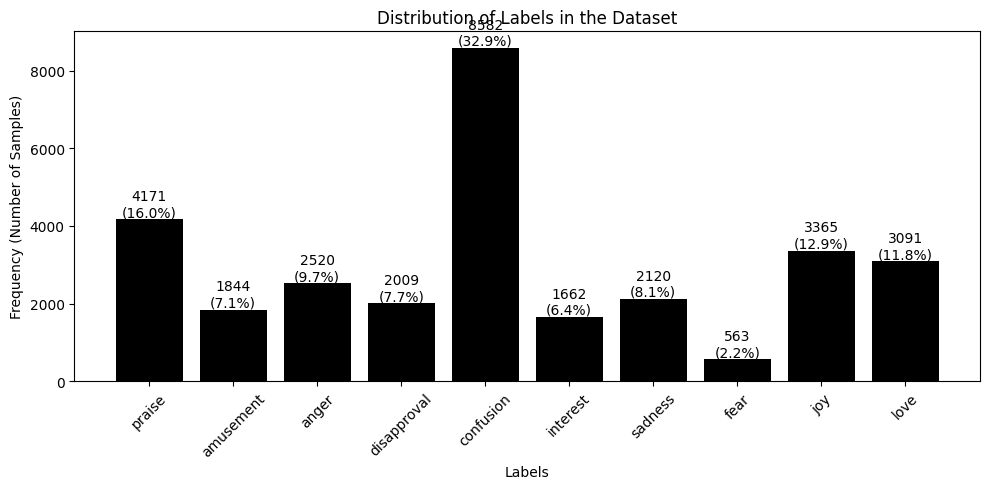

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_label_distribution(dataloader, device):
    global label_names

    total_samples = 0
    num_labels = len(label_names)
    # Initialize an array to count occurrences per label.
    label_counts = np.zeros(num_labels, dtype=np.float32)
    
    # Iterate over all batches in the dataloader
    for batch in dataloader:
        # Move the labels to the specified device and assume they are binary (0/1)
        labels = batch["targets"].to(device, dtype=torch.float)
        # Bring the labels to CPU and convert to NumPy for easier processing
        labels_np = labels.cpu().numpy()  # Shape: (batch_size, num_labels)
        
        # Sum over rows to count how many samples have each label active
        label_counts += labels_np.sum(axis=0)
        total_samples += labels_np.shape[0]
    
    # Calculate percentage for each label relative to the total number of samples
    percentages = (label_counts / total_samples) * 100
    
    # Create the bar plot
    plt.figure(figsize=(10, 5))
    bars = plt.bar(label_names, label_counts, color='black')
    plt.xlabel("Labels")
    plt.ylabel("Frequency (Number of Samples)")
    plt.title("Distribution of Labels in the Dataset")
    plt.xticks(rotation=45)
    
    # Annotate each bar with its frequency and percentage
    for bar, count, percent in zip(bars, label_counts, percentages):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{int(count)}\n({percent:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10
        )
    
    plt.tight_layout()
    plt.show()
plot_label_distribution(test_loader, device)


In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, hamming_loss
from collections import Counter
import pandas as pd


# Define label names in the correct order
label_names = [
    'praise', 'amusement', 'anger', 'disapproval', 'confusion',
    'interest', 'sadness', 'fear', 'joy', 'love'
]

def error_analysis(model, dataloader, num_active_labels, device, threshold=0.5):
    """
    Analyzes classification performance for samples with a specific number of active labels.

    Args:
    - model (torch.nn.Module): Trained classifier model.
    - dataloader (torch.utils.data.DataLoader): Validation data loader.
    - num_active_labels (int): Number of active labels to filter for analysis.
    - device (torch.device): Device (CPU or CUDA).
    - threshold (float): Decision threshold for multi-label classification.

    Returns:
    - None (displays visualizations and prints metrics).
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    label_counts = Counter()

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = prepare_batch(batch, device)

            # Filter based on the number of active labels
            active_labels = labels.sum(dim=1)
            mask = (active_labels == num_active_labels)

            if mask.sum().item() == 0:
                continue  # Skip batch if no samples match criteria

            filtered_input_ids = input_ids[mask]
            filtered_attention_mask = attention_mask[mask]
            filtered_labels = labels[mask]

            # Get model outputs
            outputs = model(input_ids=filtered_input_ids, attention_mask=filtered_attention_mask)
            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()  # Convert to binary predictions

            # Store results
            all_labels.append(filtered_labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

            # Count occurrences of each label for imbalance analysis
            batch_counts = filtered_labels.sum(dim=0).cpu().numpy().astype(int)
            for i, count in enumerate(batch_counts):
                label_counts[i] += count

    # Concatenate all batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)


    num_labels = all_labels.shape[1]
    label_metrics = {"Label": [], "Precision": [], "Recall": [], "F1-score": [], "Accuracy": []}

# Compute metrics per label and build the metrics dictionary
    for i in range(num_labels):
        precision = precision_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        recall = recall_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        f1 = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        accuracy = accuracy_score(all_labels[:, i], all_preds[:, i])

        label_metrics["Label"].append(label_names[i])  # Use provided label names
        label_metrics["Precision"].append(precision)
        label_metrics["Recall"].append(recall)
        label_metrics["F1-score"].append(f1)
        label_metrics["Accuracy"].append(accuracy)

    df_metrics = pd.DataFrame(label_metrics)

    # Plot dataset imbalance with annotations
    plt.figure(figsize=(10, 5))
    imbalance_values = [label_counts.get(i, 0) for i in range(num_labels)]
    bars = plt.bar(label_names, imbalance_values)
    plt.xlabel("Label")
    plt.ylabel("Number of Samples")
    plt.title(f"Dataset Imbalance - Samples with {num_active_labels} Active Labels")
    plt.xticks(rotation=45)

    # Annotate each bar with its height (count value)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', 
                ha='center', va='bottom')

    plt.show()

    # Define metrics to plot, including Accuracy now
    metrics_to_plot = ["Precision", "Recall", "F1-score", "Accuracy"]

    # Plot classification metrics with annotations
    for metric in metrics_to_plot:
        plt.figure(figsize=(10, 5))
        bars = plt.bar(df_metrics["Label"], df_metrics[metric], label=metric)
        plt.xlabel("Label")
        plt.ylabel(metric)
        plt.title(f"{metric} per Label (Filtered: {num_active_labels} Active Labels)")
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        plt.legend()
        
        # Annotate each bar with its value (formatted to 2 decimal places)
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
                    ha='center', va='bottom')
        
        plt.show()
    avg_hamming_score = 1 - hamming_loss(all_labels, all_preds)


    # Print and save metrics
    print("\nClassification Metrics Table:")
    print(df_metrics.to_string())  # Print table in console
    df_metrics.to_csv("classification_metrics.csv", index=False)  # Save as CSV
    print("hamming score: ",avg_hamming_score)

    print(f"\n✅ Error analysis completed for samples with {num_active_labels} active labels.")

    # Example usage:
    # error_analysis(trained_model, memoized_valid, num_active_labels=1, device=torch.device("cuda"))


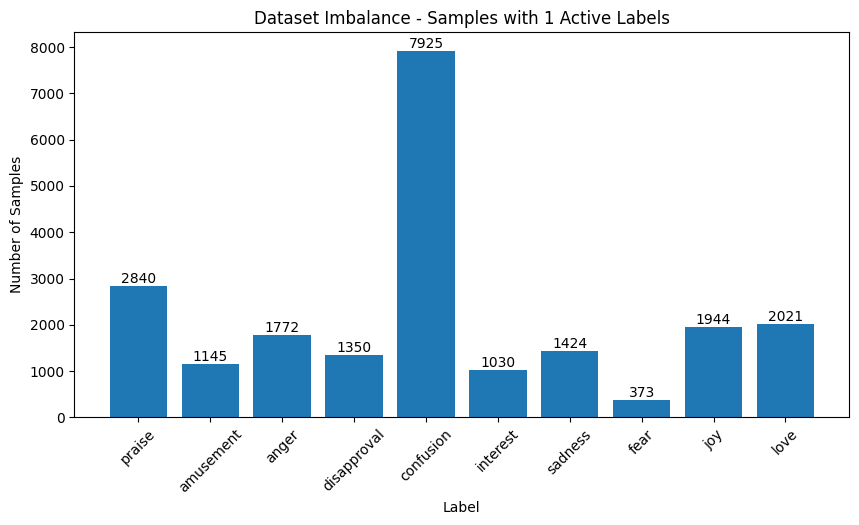

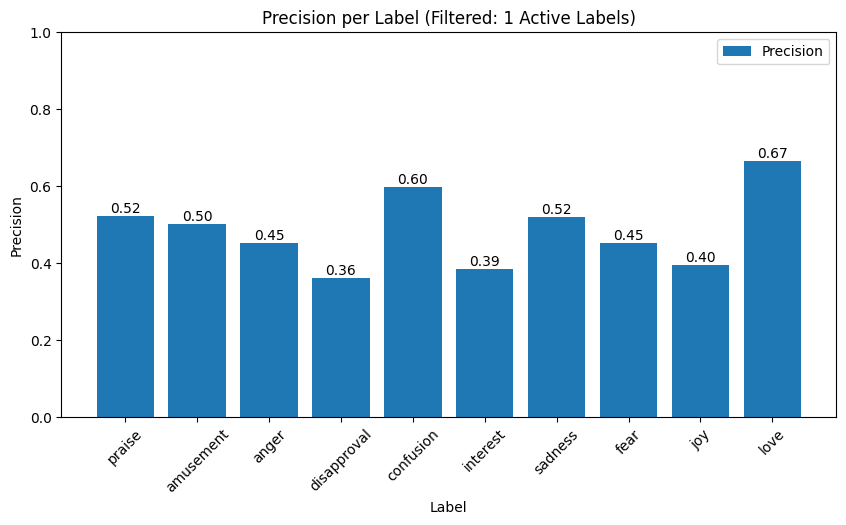

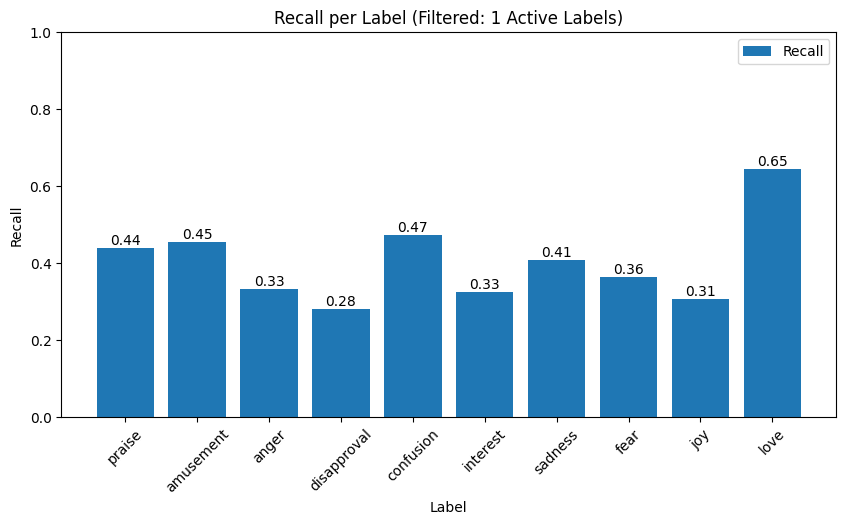

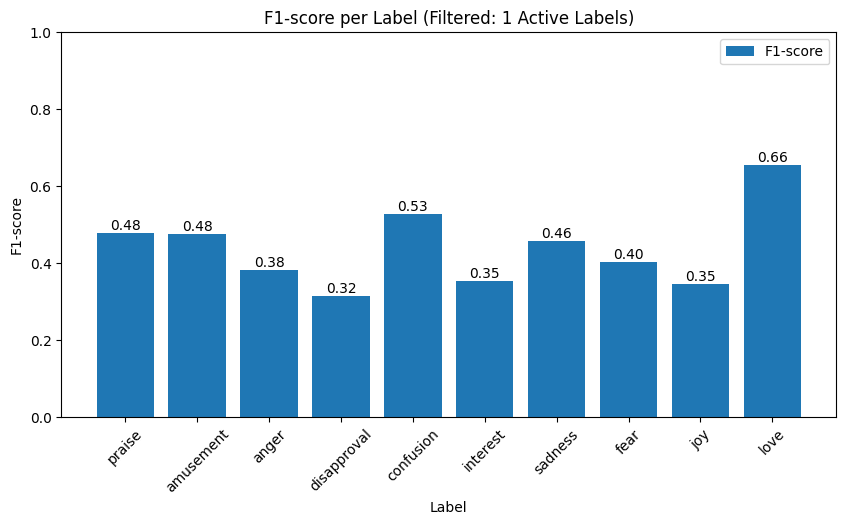

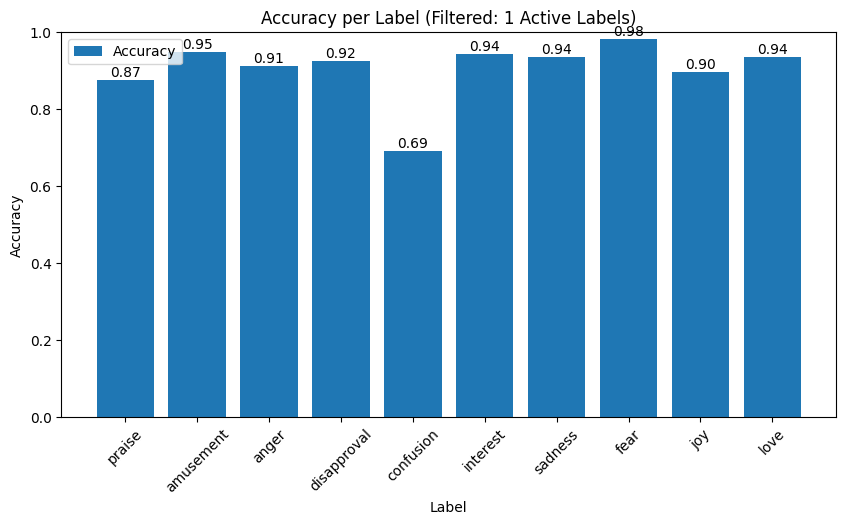


Classification Metrics Table:
         Label  Precision    Recall  F1-score  Accuracy
0       praise   0.523013  0.440141  0.478011  0.874908
1    amusement   0.502901  0.454148  0.477283  0.947810
2        anger   0.452729  0.332393  0.383339  0.913169
3  disapproval   0.361987  0.280741  0.316229  0.924899
4    confusion   0.597446  0.472303  0.527555  0.692815
5     interest   0.386207  0.326214  0.353684  0.943732
6      sadness   0.519678  0.408006  0.457120  0.936767
7         fear   0.453333  0.364611  0.404160  0.981626
8          joy   0.396689  0.308128  0.346844  0.896628
9         love   0.665646  0.645225  0.655276  0.937133
hamming score:  0.9049486803519061

✅ Error analysis completed for samples with 1 active labels.


In [45]:
error_analysis(model, test_loader, num_active_labels=1, device=torch.device("cuda"))

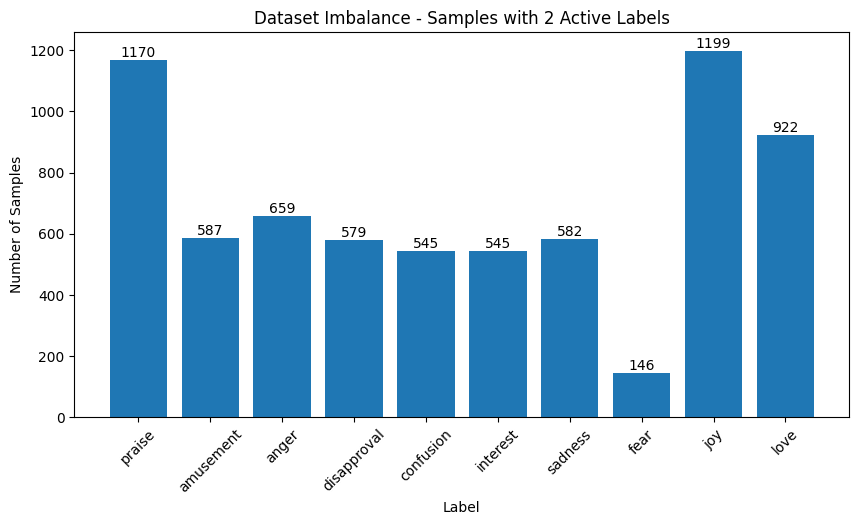

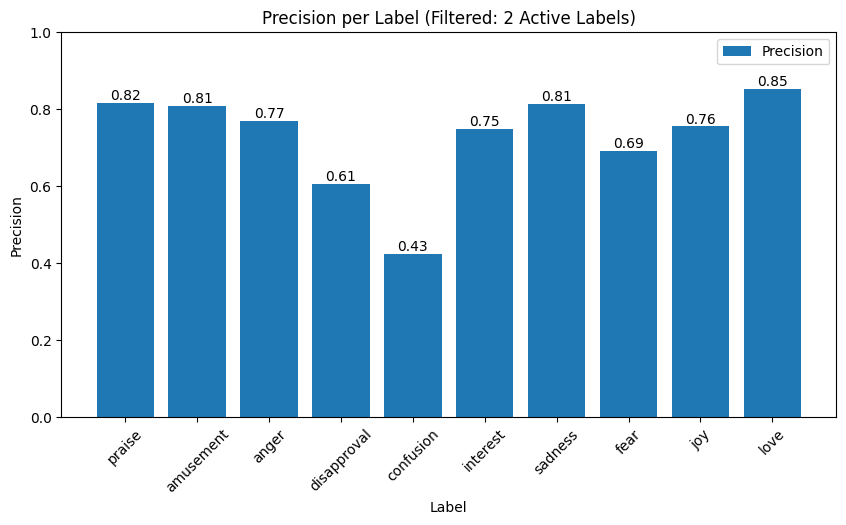

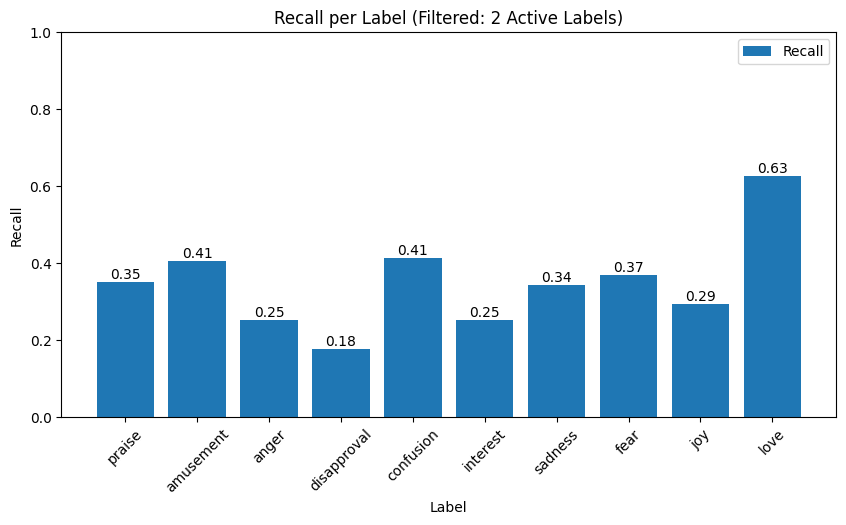

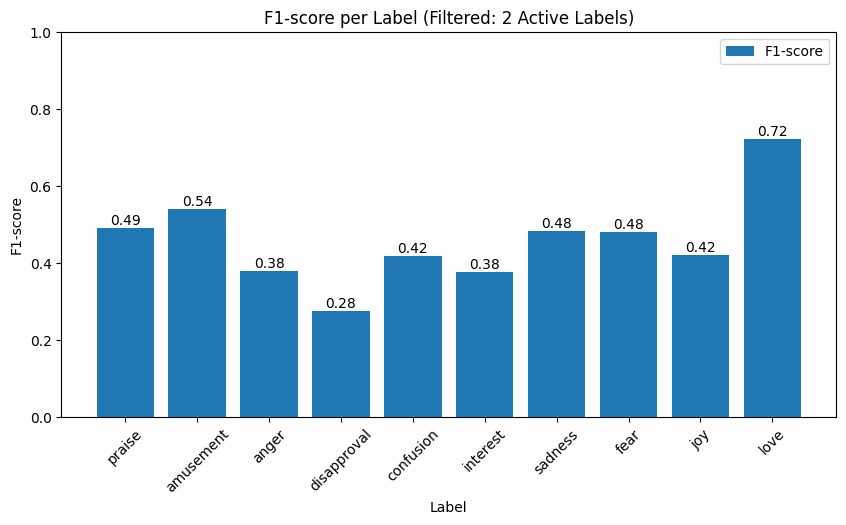

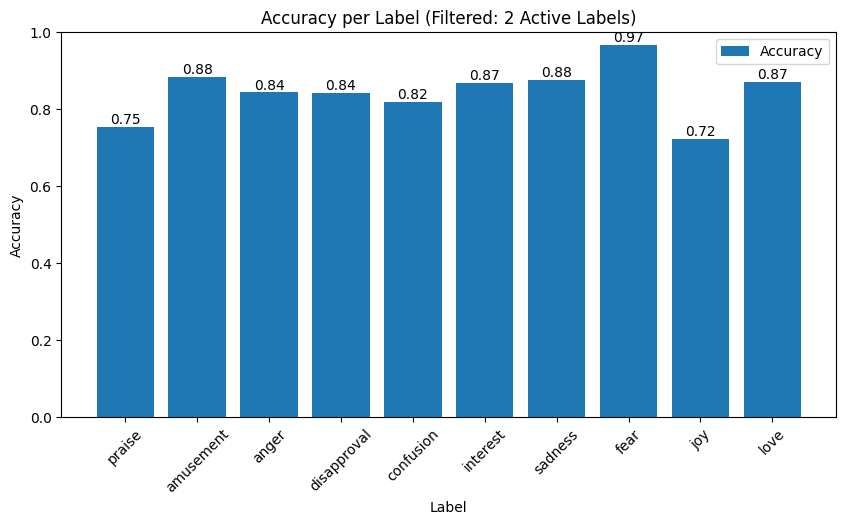


Classification Metrics Table:
         Label  Precision    Recall  F1-score  Accuracy
0       praise   0.817460  0.352137  0.492234  0.754831
1    amusement   0.807432  0.407155  0.541336  0.883184
2        anger   0.769585  0.253414  0.381279  0.843669
3  disapproval   0.605882  0.177893  0.275033  0.843380
4    confusion   0.425331  0.412844  0.418994  0.820017
5     interest   0.750000  0.253211  0.378601  0.869339
6      sadness   0.813008  0.343643  0.483092  0.876550
7         fear   0.692308  0.369863  0.482143  0.966542
8          joy   0.755365  0.293578  0.422823  0.722815
9         love   0.852725  0.627983  0.723298  0.872224
hamming score:  0.8452552639169311

✅ Error analysis completed for samples with 2 active labels.


In [46]:
error_analysis(model, test_loader, num_active_labels=2, device=torch.device("cuda"))

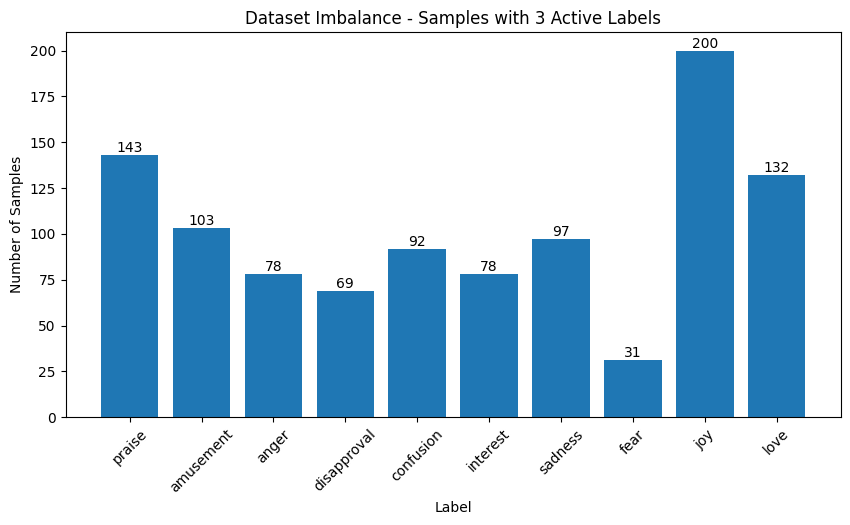

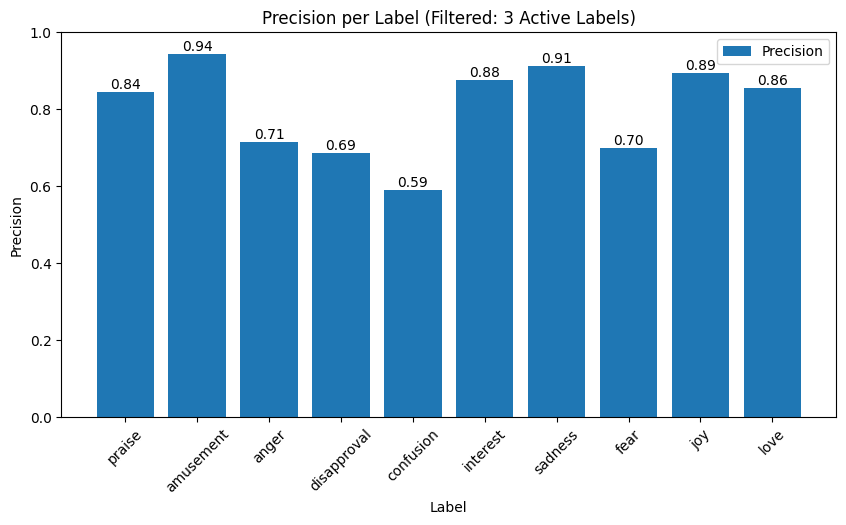

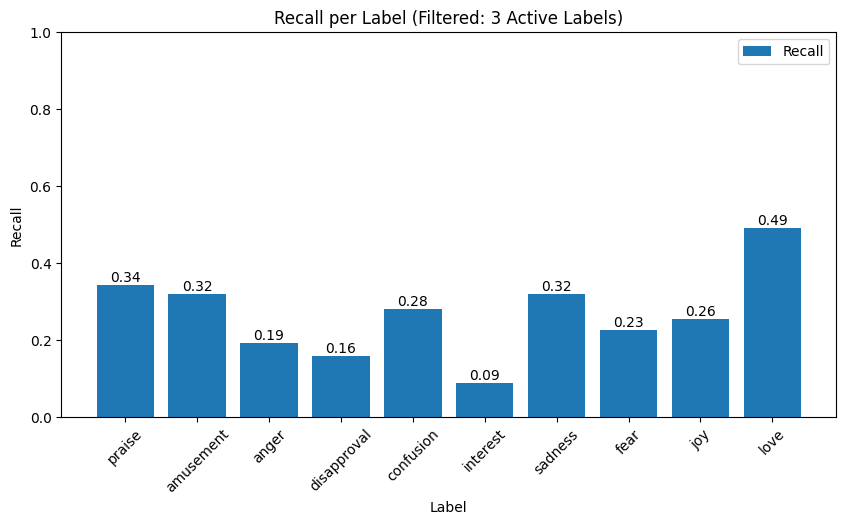

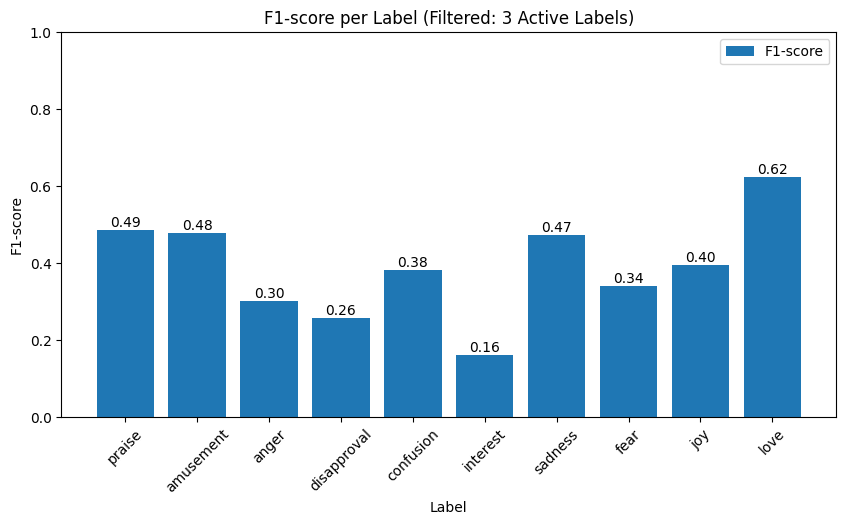

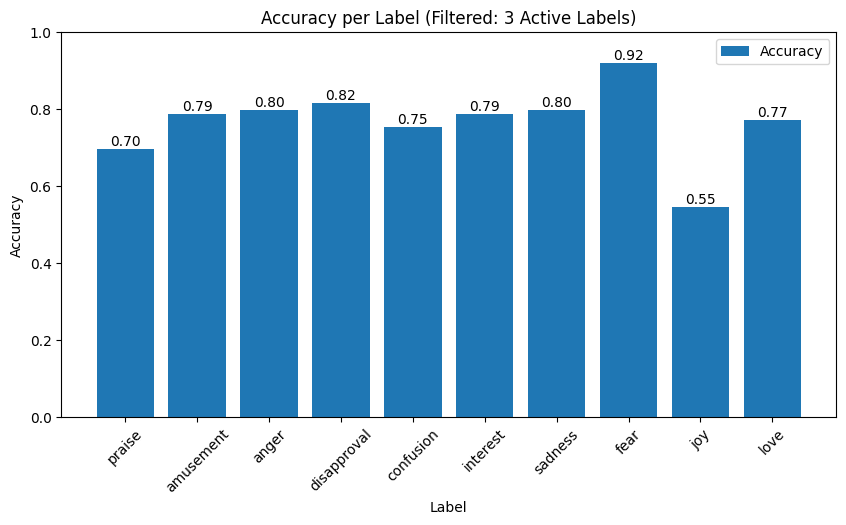


Classification Metrics Table:
         Label  Precision    Recall  F1-score  Accuracy
0       praise   0.844828  0.342657  0.487562  0.697947
1    amusement   0.942857  0.320388  0.478261  0.788856
2        anger   0.714286  0.192308  0.303030  0.797654
3  disapproval   0.687500  0.159420  0.258824  0.815249
4    confusion   0.590909  0.282609  0.382353  0.753666
5     interest   0.875000  0.089744  0.162791  0.788856
6      sadness   0.911765  0.319588  0.473282  0.797654
7         fear   0.700000  0.225806  0.341463  0.920821
8          joy   0.894737  0.255000  0.396887  0.545455
9         love   0.855263  0.492424  0.625000  0.771261
hamming score:  0.7677419354838709

✅ Error analysis completed for samples with 3 active labels.


In [48]:
error_analysis(model, test_loader, num_active_labels=3, device=torch.device("cuda"))

### Evaluate Test

In [ ]:
Test_path = 'FinalEmoTest_1000.csv'  # Update with your file path
Test_df = pd.read_csv(valid_path)

In [73]:
tokenizer = EmotionTokenizer(model_name=MODEL_NAME, max_len=MAX_LEN)

test_sample_loader = prepare_dataloader(Test_df,
                                    tokenizer,
                                    label_names,
                                    batch_size=32,
                                    shuffle=False)

In [88]:
val_loss, macro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc, hammin_score = evaluate(
    model, test_sample_loader, criterion, torch.device("cuda"), threshold=0.30
)
print(f"macro_f1 (0.30th): {macro_f1}")
print(f"hard_accuracy (0.30th): {hard_accuracy}")
print(f"macro_precision (0.30th): {micro_precision}")
print(f"macro_recall (0.30th): {micro_recall}")
print(f"roc_auc (0.30th): {roc_auc}")
print(f"hamming_score (0.30th): {hammin_score}")

Evaluating: 100%|██████████| 331/331 [00:27<00:00, 12.13it/s]

macro_f1 (0.30th): 0.4786114875712464
hard_accuracy (0.30th): 0.2974815375875781
macro_precision (0.30th): 0.42480113366390687
macro_recall (0.30th): 0.5503316532190976
roc_auc (0.30th): 0.7467959993264327
hamming_score (0.30th): 0.8685476235561447


In [90]:
val_loss, macro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc, hammin_score = evaluate(
    model, test_sample_loader, criterion, torch.device("cuda"), threshold=0.32
)
print(f"macro_f1 (0.32th): {macro_f1}")
print(f"hard_accuracy (0.32th): {hard_accuracy}")
print(f"macro_precision (0.32th): {micro_precision}")
print(f"macro_recall (0.32th): {micro_recall}")
print(f"roc_auc (0.32th): {roc_auc}")
print(f"hamming_score (0.32th): {hammin_score}")

Evaluating: 100%|██████████| 331/331 [00:26<00:00, 12.64it/s]

macro_f1 (0.32th): 0.4806102569504411
hard_accuracy (0.32th): 0.32010982768415075
macro_precision (0.32th): 0.43818661962254896
macro_recall (0.32th): 0.5339840673904881
roc_auc (0.32th): 0.7410279445572526
hamming_score (0.32th): 0.8735656125733763


In [91]:
val_loss, macro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc, hammin_score = evaluate(
    model, test_sample_loader, criterion, torch.device("cuda"), threshold=0.35
)
print(f"macro_f1 (0.35th): {macro_f1}")
print(f"hard_accuracy (0.35th): {hard_accuracy}")
print(f"macro_precision (0.35th): {micro_precision}")
print(f"macro_recall (0.35th): {micro_recall}")
print(f"roc_auc (0.35th): {roc_auc}")
print(f"hamming_score (0.35th): {hammin_score}")

Evaluating: 100%|██████████| 331/331 [00:26<00:00, 12.62it/s]

macro_f1 (0.35th): 0.4776983412603122
hard_accuracy (0.35th): 0.3432115129710282
macro_precision (0.35th): 0.4546877598068518
macro_recall (0.35th): 0.5046089143944351
roc_auc (0.35th): 0.7307487769033736
hamming_score (0.35th): 0.8791990153380042


In [92]:
val_loss, macro_f1, hard_accuracy, micro_precision, micro_recall, roc_auc, hammin_score = evaluate(
    model, test_sample_loader, criterion, torch.device("cuda"), threshold=0.50
)
print(f"macro_f1 (0.50th): {macro_f1}")
print(f"hard_accuracy (0.50th): {hard_accuracy}")
print(f"macro_precision (0.50th): {micro_precision}")
print(f"macro_recall (0.50th): {micro_recall}")
print(f"roc_auc (0.50th): {roc_auc}")
print(f"hamming_score (0.50th): {hammin_score}")

Evaluating: 100%|██████████| 331/331 [00:27<00:00, 12.26it/s]

macro_f1 (0.50th): 0.4448778825565345
hard_accuracy (0.50th): 0.35466767657640597
macro_precision (0.50th): 0.5306440152816
macro_recall (0.50th): 0.3855029424323436
roc_auc (0.50th): 0.6847306432279273
hamming_score (0.50th): 0.8954743419806854


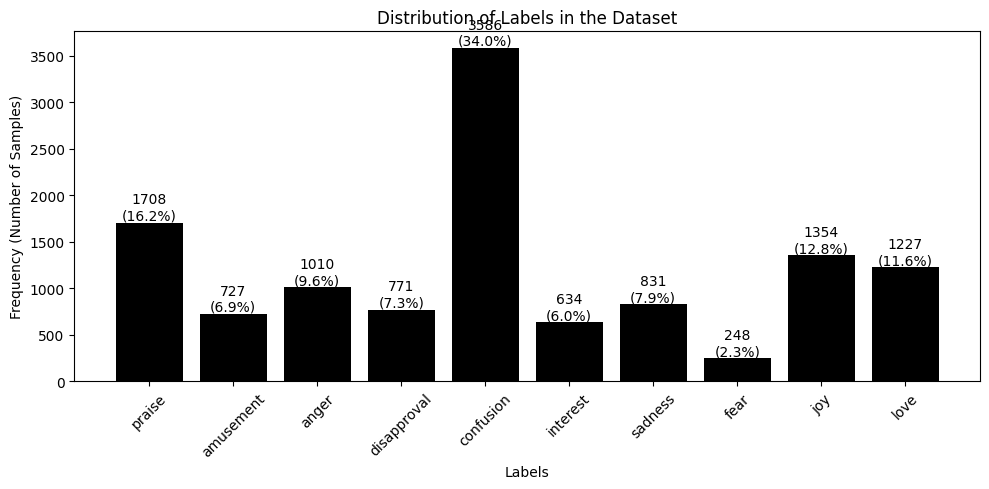

In [83]:
plot_label_distribution(test_sample_loader, device)

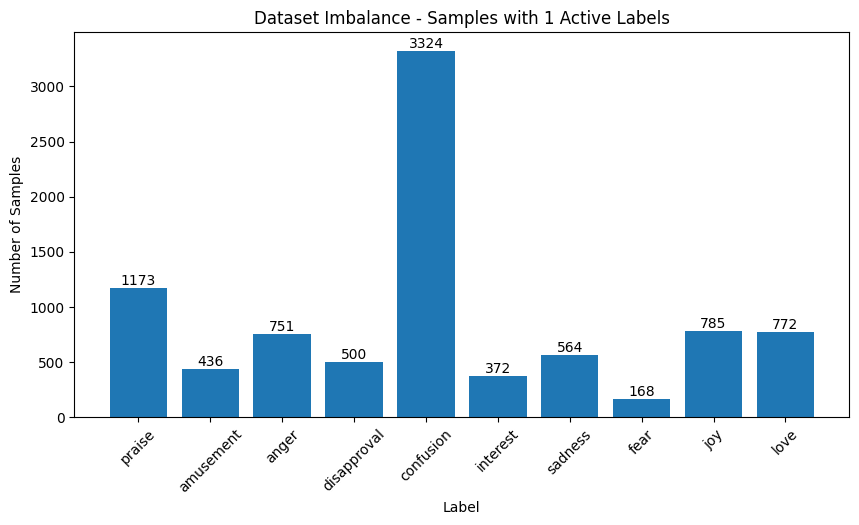

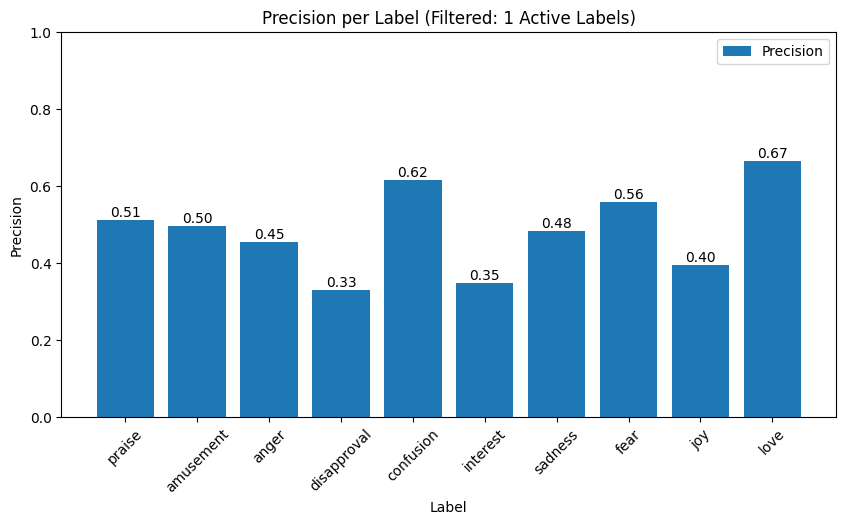

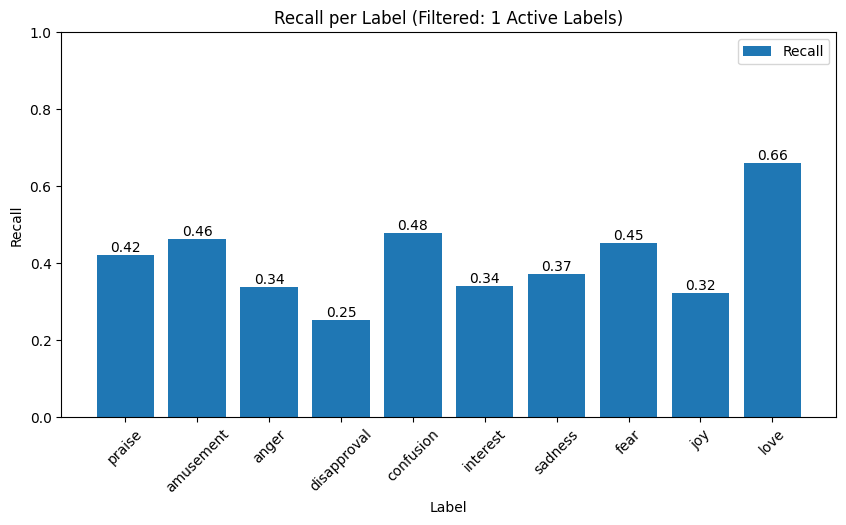

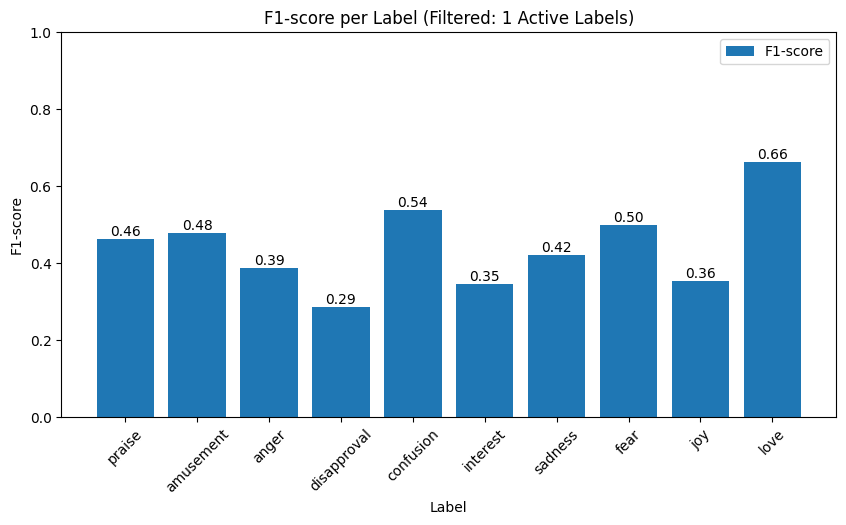

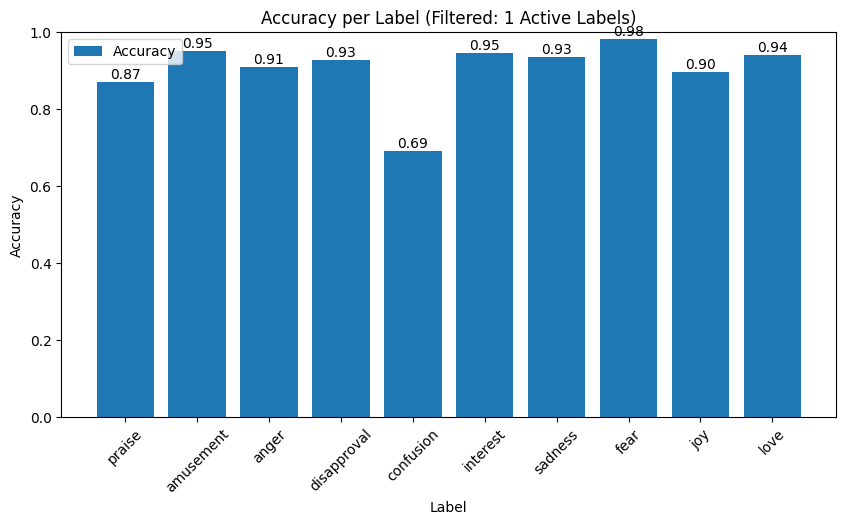


Classification Metrics Table:
         Label  Precision    Recall  F1-score  Accuracy
0       praise   0.512927  0.422847  0.463551  0.870209
1    amusement   0.497537  0.463303  0.479810  0.950480
2        anger   0.454383  0.338216  0.387786  0.909327
3  disapproval   0.329843  0.252000  0.285714  0.928773
4    confusion   0.617054  0.478941  0.539295  0.692482
5     interest   0.349862  0.341398  0.345578  0.945619
6      sadness   0.484988  0.372340  0.421264  0.934765
7         fear   0.558824  0.452381  0.500000  0.982815
8          joy   0.395931  0.322293  0.355337  0.896213
9         love   0.665796  0.660622  0.663199  0.941436
hamming score:  0.9052119841718484

✅ Error analysis completed for samples with 1 active labels.


In [80]:
# import ipdb; ipdb.set_trace()
error_analysis(model, test_sample_loader, num_active_labels=1, device=torch.device("cuda"))

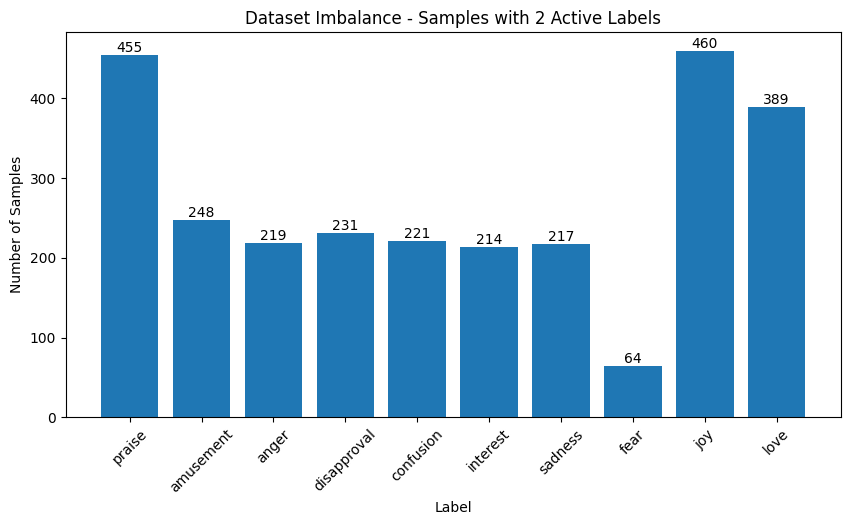

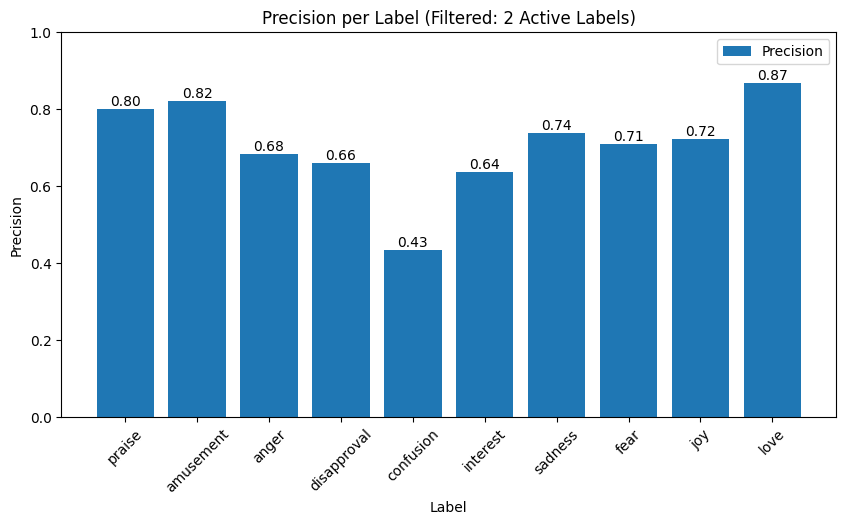

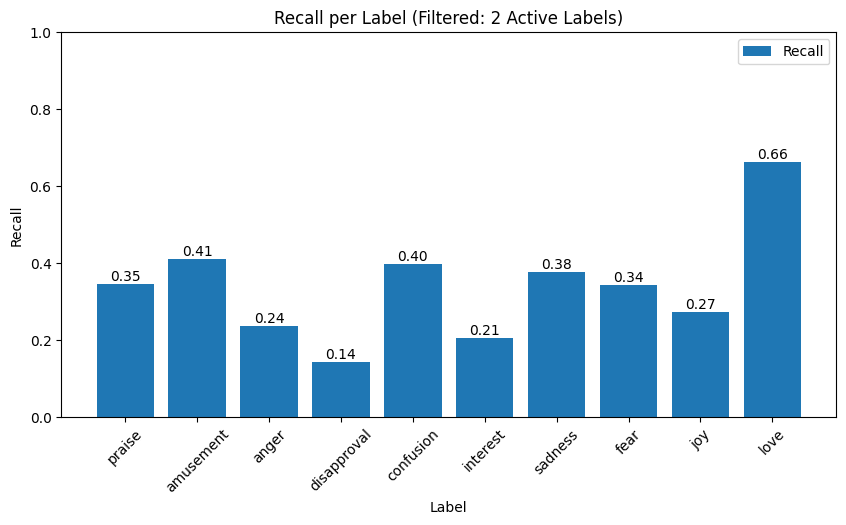

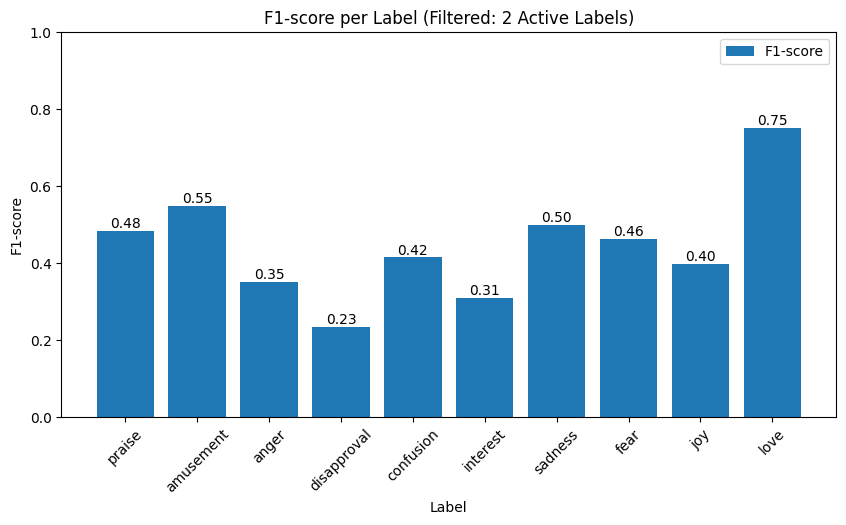

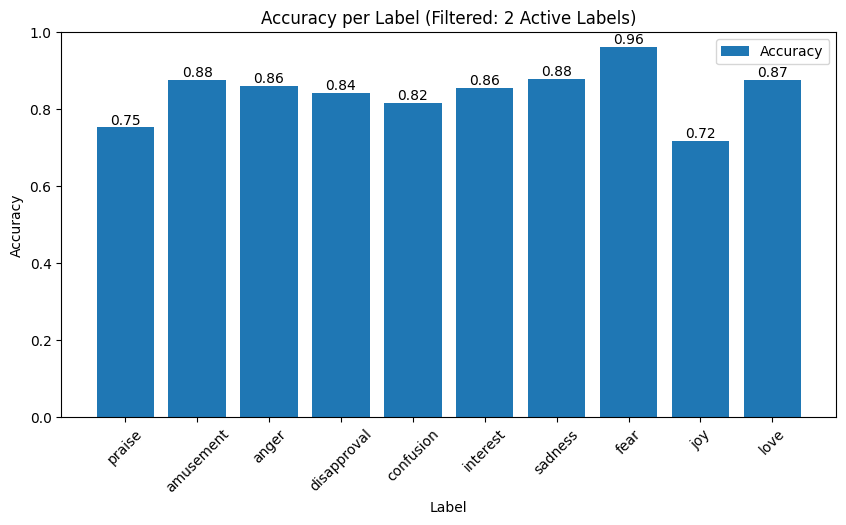


Classification Metrics Table:
         Label  Precision    Recall  F1-score  Accuracy
0       praise   0.802030  0.347253  0.484663  0.752759
1    amusement   0.822581  0.411290  0.548387  0.876380
2        anger   0.684211  0.237443  0.352542  0.859455
3  disapproval   0.660000  0.142857  0.234875  0.841795
4    confusion   0.433498  0.398190  0.415094  0.817513
5     interest   0.637681  0.205607  0.310954  0.856512
6      sadness   0.738739  0.377880  0.500000  0.879323
7         fear   0.709677  0.343750  0.463158  0.962472
8          joy   0.724138  0.273913  0.397476  0.718911
9         love   0.868687  0.663239  0.752187  0.874908
hamming score:  0.8440029433406917

✅ Error analysis completed for samples with 2 active labels.


In [81]:
error_analysis(model, test_sample_loader, num_active_labels=2, device=torch.device("cuda"))

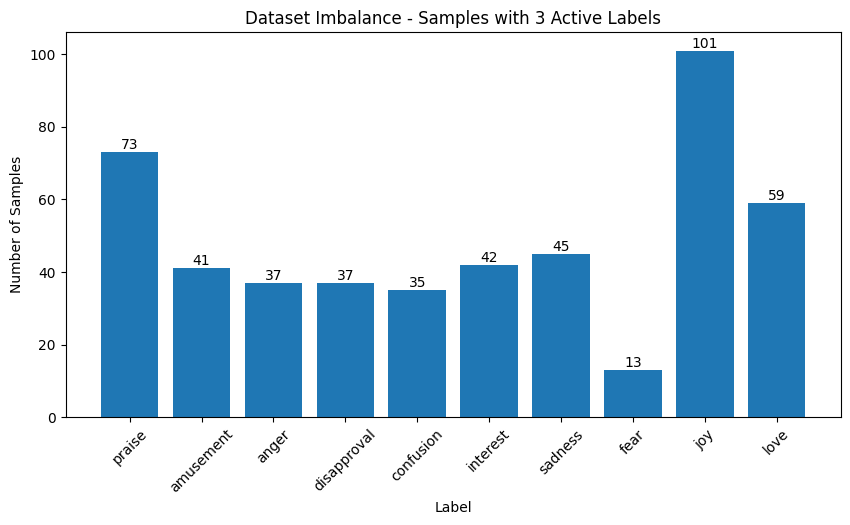

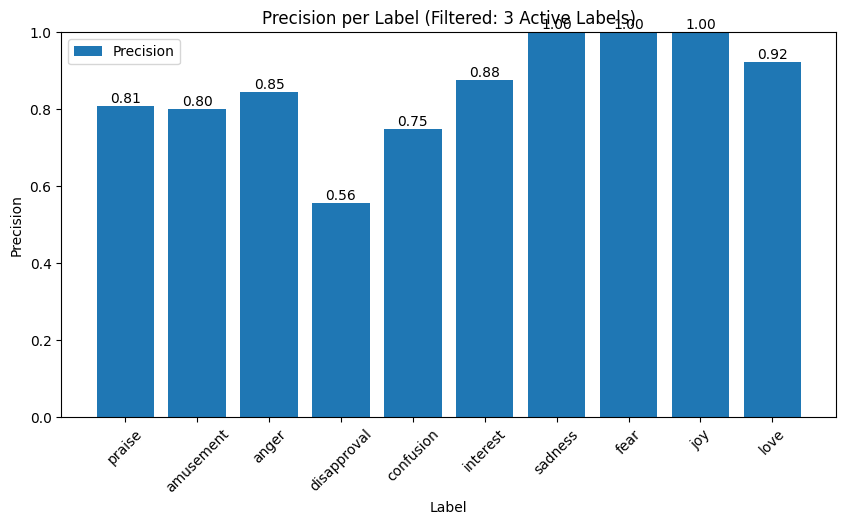

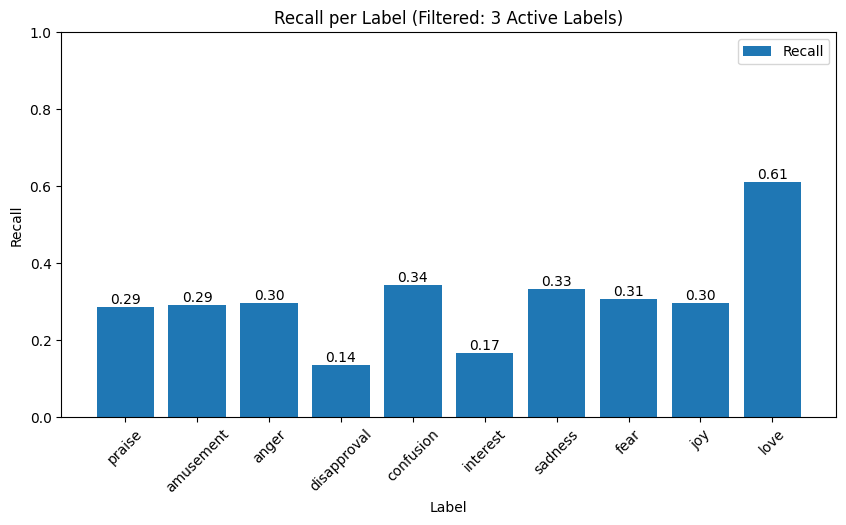

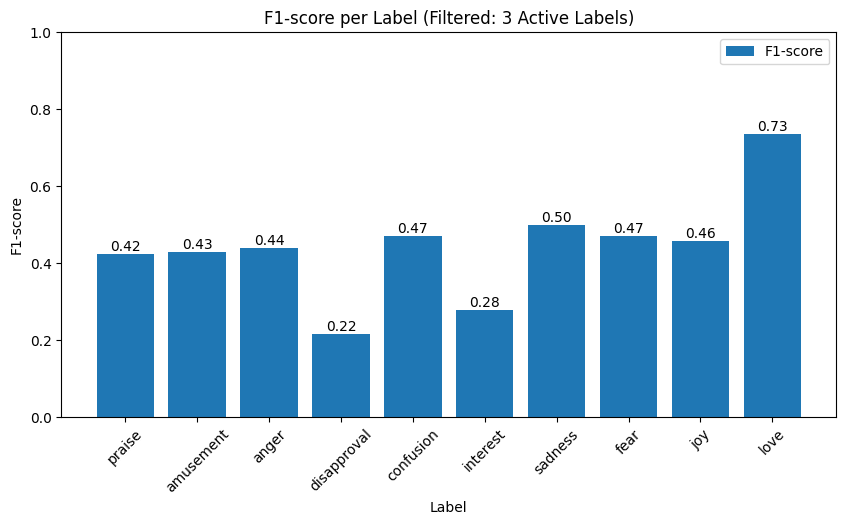

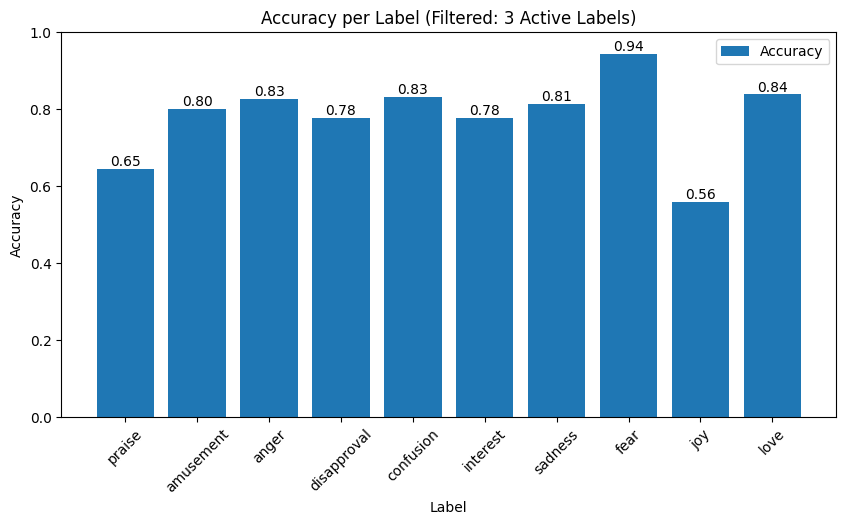


Classification Metrics Table:
         Label  Precision    Recall  F1-score  Accuracy
0       praise   0.807692  0.287671  0.424242  0.645963
1    amusement   0.800000  0.292683  0.428571  0.801242
2        anger   0.846154  0.297297  0.440000  0.826087
3  disapproval   0.555556  0.135135  0.217391  0.776398
4    confusion   0.750000  0.342857  0.470588  0.832298
5     interest   0.875000  0.166667  0.280000  0.776398
6      sadness   1.000000  0.333333  0.500000  0.813665
7         fear   1.000000  0.307692  0.470588  0.944099
8          joy   1.000000  0.297030  0.458015  0.559006
9         love   0.923077  0.610169  0.734694  0.838509
hamming score:  0.7813664596273292

✅ Error analysis completed for samples with 3 active labels.


In [82]:
error_analysis(model, test_sample_loader, num_active_labels=3, device=torch.device("cuda"))

In [105]:
import torch
import json
import os

# Define model class before loading (must match training definition)
model = DistilBERTClass(num_labels=10)  # Adjust num_labels if needed

# Specify trial directory (update the trial number as needed)
# trial_dir = f"drive/MyDrive/hp_search/best_model"

# Define the path using a raw string (best practice for Windows)
trial_dir = r"C:\Users\pouri\Desktop\study\term7\machine_learning\assignments\project\full_train"

# Load the checkpoint
checkpoint = torch.load(os.path.join(trial_dir, "full_trian.pt"))

# Load model state
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()  # Set to evaluation mode
criterion = nn.BCEWithLogitsLoss()  # multi-label
device = torch.device("cuda")
model.to(device)

DistilBERTClass(
  (l1): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(i